In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering as HierClustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import matplotlib.cm as cm

# Check python version
print(f'Running on Python v{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}')

# set the random seed
seed = 23
np.random.seed(seed)

Running on Python v3.13.5


In [2]:
filename = "reduced_dataset"
filepath = f"{filename}.csv"

# Load the dataset, raise error if file is not found
try:
    data = pd.read_csv(filepath_or_buffer = filepath, index_col = 0)
except FileNotFoundError:
    print(f"Error: file not found at {filepath}")
except Exception as error:
    print(f"An error occurred: {error}")

# Display data
data.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-1.302876,2.003823,-2.297015,-1.735465,-1.176128,0.359455,-0.178524,0.092419,-0.365157
1,11.370682,1.709007,5.995159,-0.932095,2.863412,3.218301,-0.472123,0.711302,-0.832784
2,1.097461,2.403322,-0.721315,-1.522268,-0.361365,1.280827,-0.438102,0.286522,-0.438782
3,-1.601349,2.317258,-2.063709,-1.628483,-1.817311,0.603256,-0.377040,1.398919,0.520320
4,-7.074164,-7.673819,2.810652,-4.416465,2.562533,-0.270394,-1.866927,0.911944,1.703471


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     75 non-null     float64
 1   PC2     75 non-null     float64
 2   PC3     75 non-null     float64
 3   PC4     75 non-null     float64
 4   PC5     75 non-null     float64
 5   PC6     75 non-null     float64
 6   PC7     75 non-null     float64
 7   PC8     75 non-null     float64
 8   PC9     75 non-null     float64
dtypes: float64(9)
memory usage: 5.4 KB


# K-Means Clustering:

In [4]:
def radviz(dataframe: pd.DataFrame, ax, labels, colors):

    ax = plt.gca()

    # Plot origin
    plt.plot(
        0, 0,
        marker = "o",
        color = "black",
        markersize = 10,
        zorder = 1
    )

    # Make a point for each feature
    num_features = len(dataframe.columns) - 1

    for feature in range(num_features):
        point = [
            np.cos(feature * ((2 * np.pi) / num_features)),
            np.sin(feature * ((2 * np.pi) / num_features)),
        ]

        # Make dashed lines leading to the features
        plt.plot(
            [0, point[0]],
            [0, point[1]],
            linestyle = "--",
            color = "black",
            zorder = 0
        )


    # Create the radviz plot
    pd.plotting.radviz(
        frame = dataframe,
        class_column = labels,
        color = colors,
        marker = "o",
        s = 120,
        zorder = 2
    )

    # Format the legend and axes
    ax.get_legend().set_visible(False)
    # ax.legend(fontsize = 14).get_frame().set_edgecolor('black')
    ax.set_axis_off()

    # Change the fontsize of the feature labels
    for label in ax.texts:
        label.set_fontsize(10)

    # Make concentric circles to connect column labels and show distances
    radii = np.arange(0.05, 0.85 + 0.01, 0.1)
    radii = np.append(radii, 1)

    # Circle generating function
    def circles(radius):
        circle = plt.Circle(
            (0, 0),
            radius = radius,
            color = 'black',
            linestyle = '--',
            fill = False,
            zorder = 0
        )
        ax.add_patch(circle)

        return

    # Loop through all radii
    for radius in radii:
        if radius != 1:
            circles(radius)
        else:
            circle = plt.Circle((0, 0), radius = radius, color = 'black', fill = False, zorder = 0)
            ax.add_patch(circle)

    return

In [5]:
# Normalizing Data for Radviz Plot
normalized = (data - data.min())/(data.max() - data.min())

# Print Results
print(f'{normalized.agg(['min', 'max'])}')

     PC1  PC2  PC3  PC4  PC5  PC6  PC7  PC8  PC9
min  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
max  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0


For n_clusters = 2 The average silhouette_score is : 0.2414518595485502
For n_clusters = 3 The average silhouette_score is : 0.28773480295109055
For n_clusters = 4 The average silhouette_score is : 0.3664357694577178
For n_clusters = 5 The average silhouette_score is : 0.4173506671369035
For n_clusters = 6 The average silhouette_score is : 0.44972935651756357
For n_clusters = 7 The average silhouette_score is : 0.4775997204556138
For n_clusters = 8 The average silhouette_score is : 0.5246580094041594
For n_clusters = 9 The average silhouette_score is : 0.5373145614216864
For n_clusters = 10 The average silhouette_score is : 0.5821963413561522
For n_clusters = 11 The average silhouette_score is : 0.589105530622085
For n_clusters = 12 The average silhouette_score is : 0.6088366769172275
For n_clusters = 13 The average silhouette_score is : 0.58739878802634
For n_clusters = 14 The average silhouette_score is : 0.5770367372015889
For n_clusters = 15 The average silhouette_score is : 0.5025

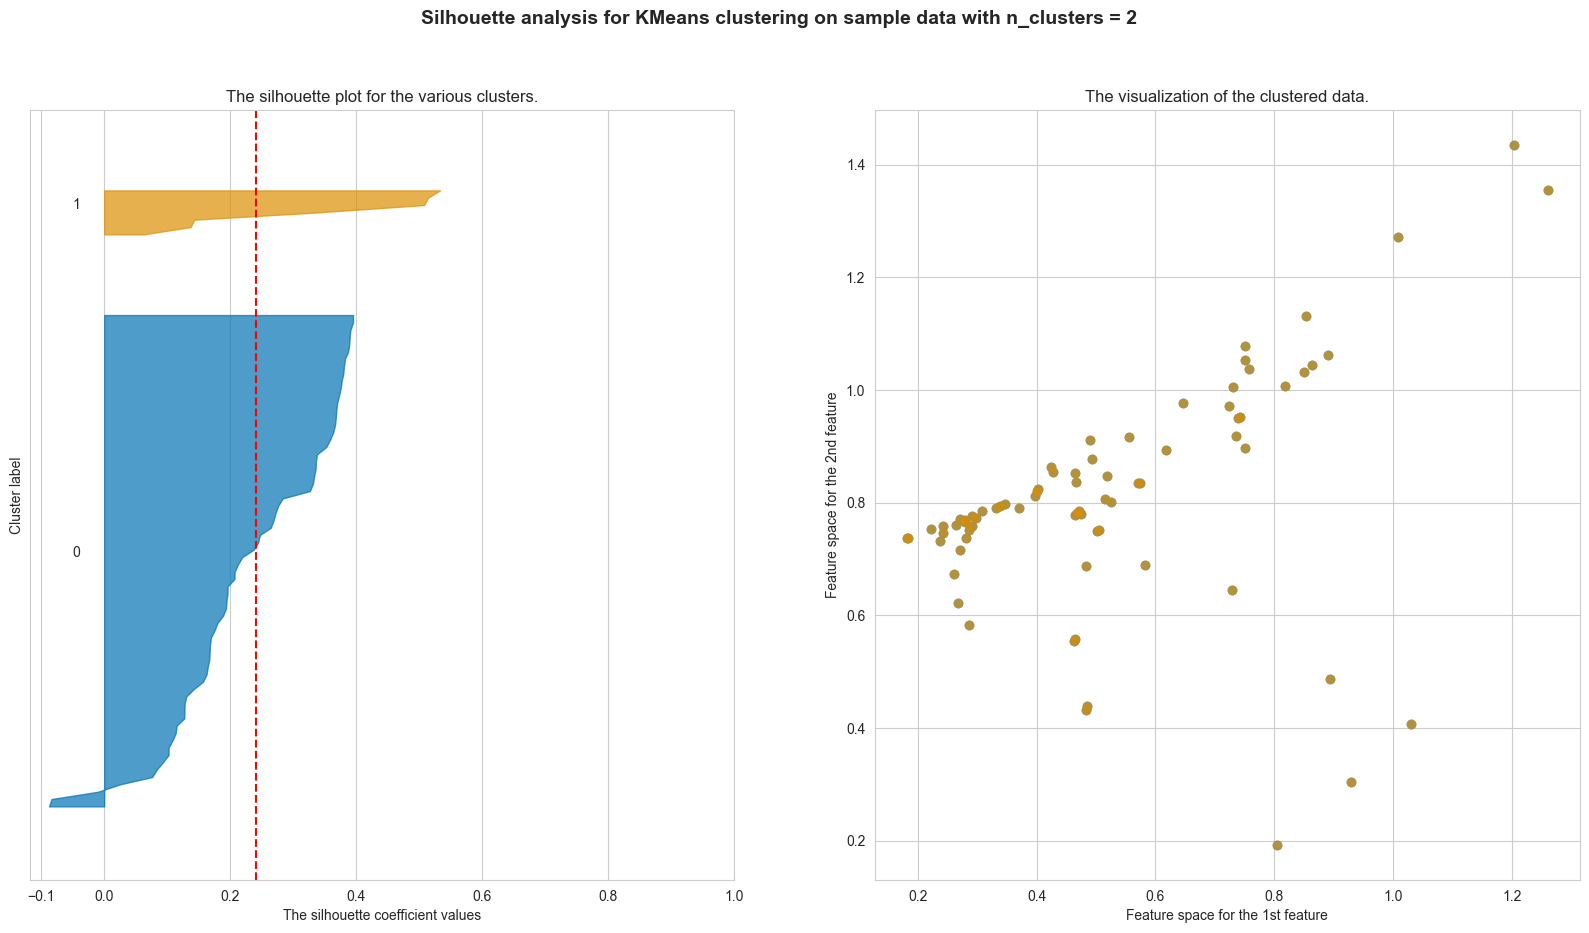

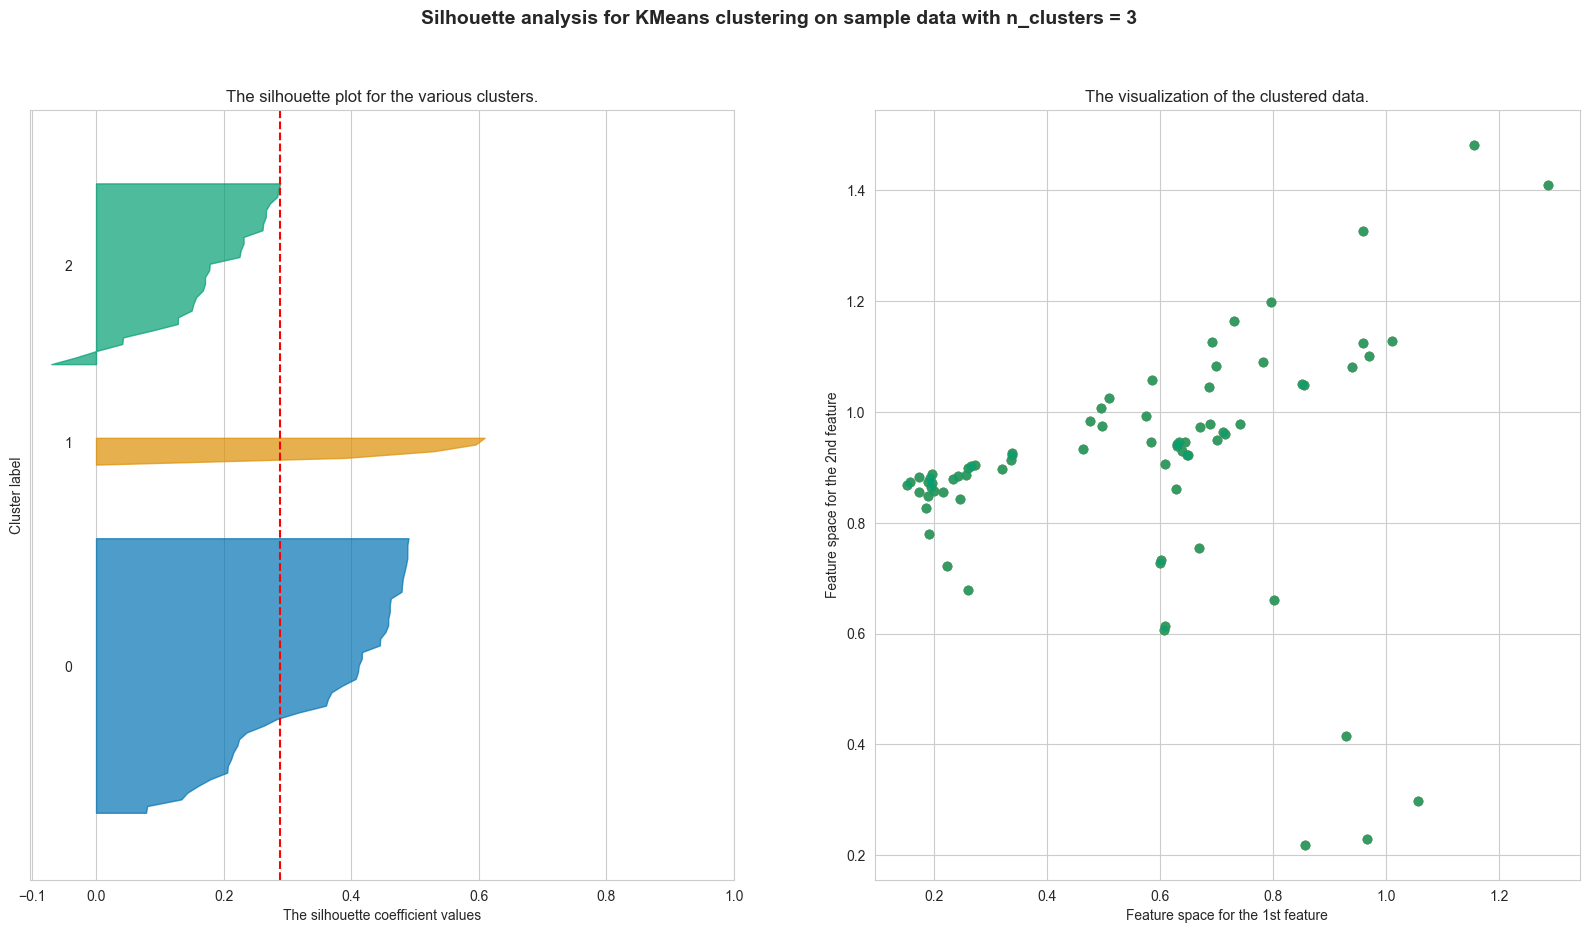

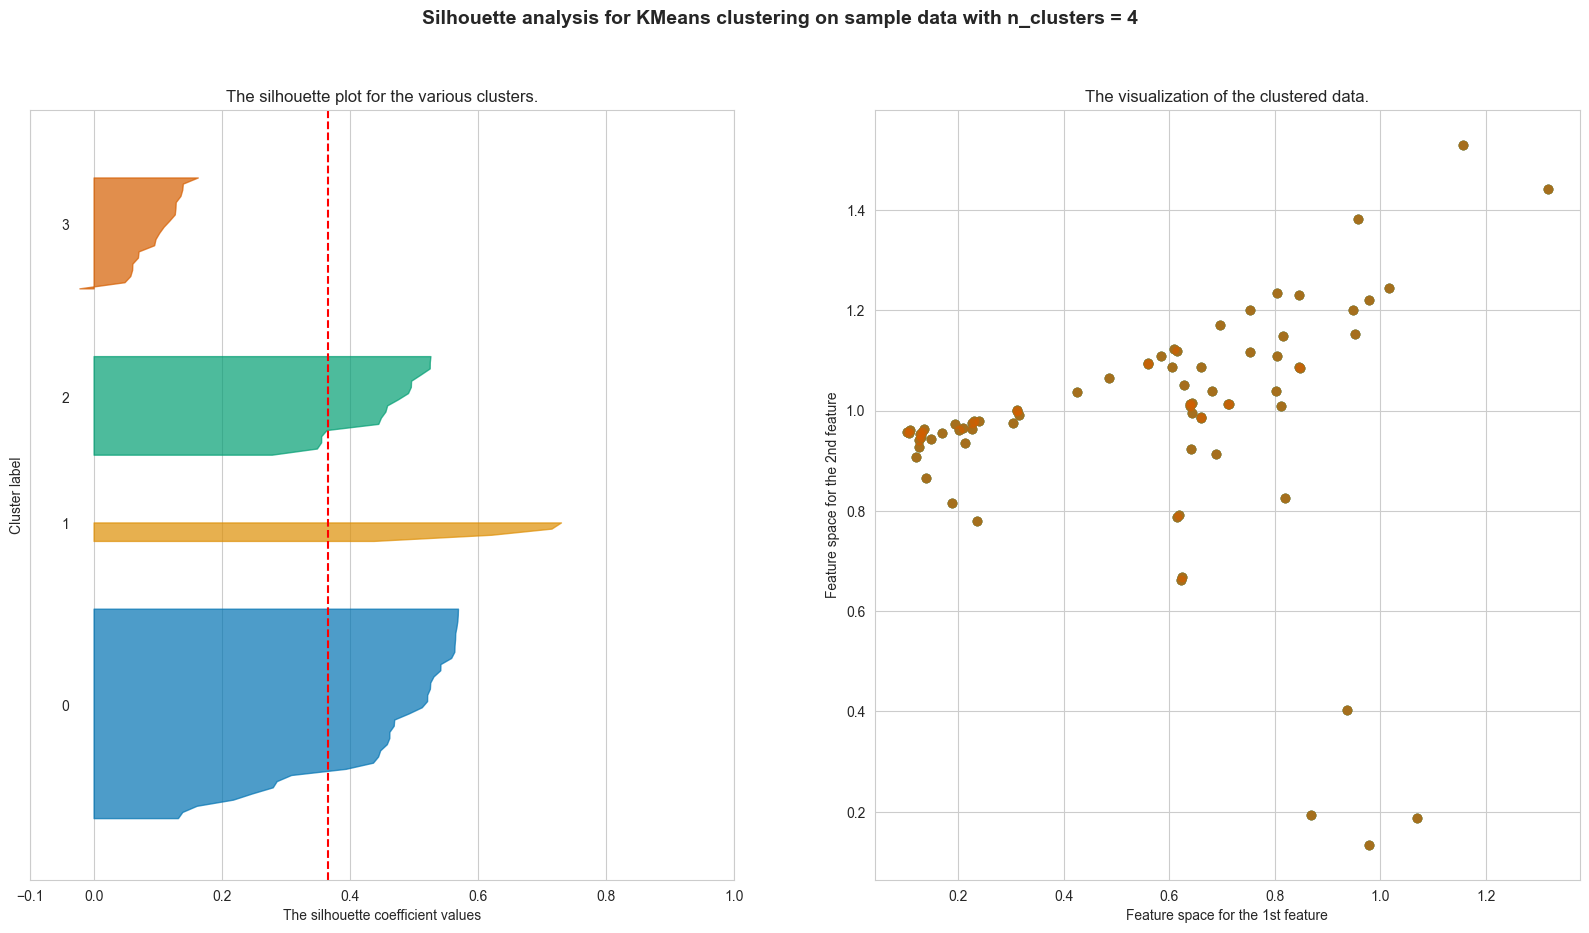

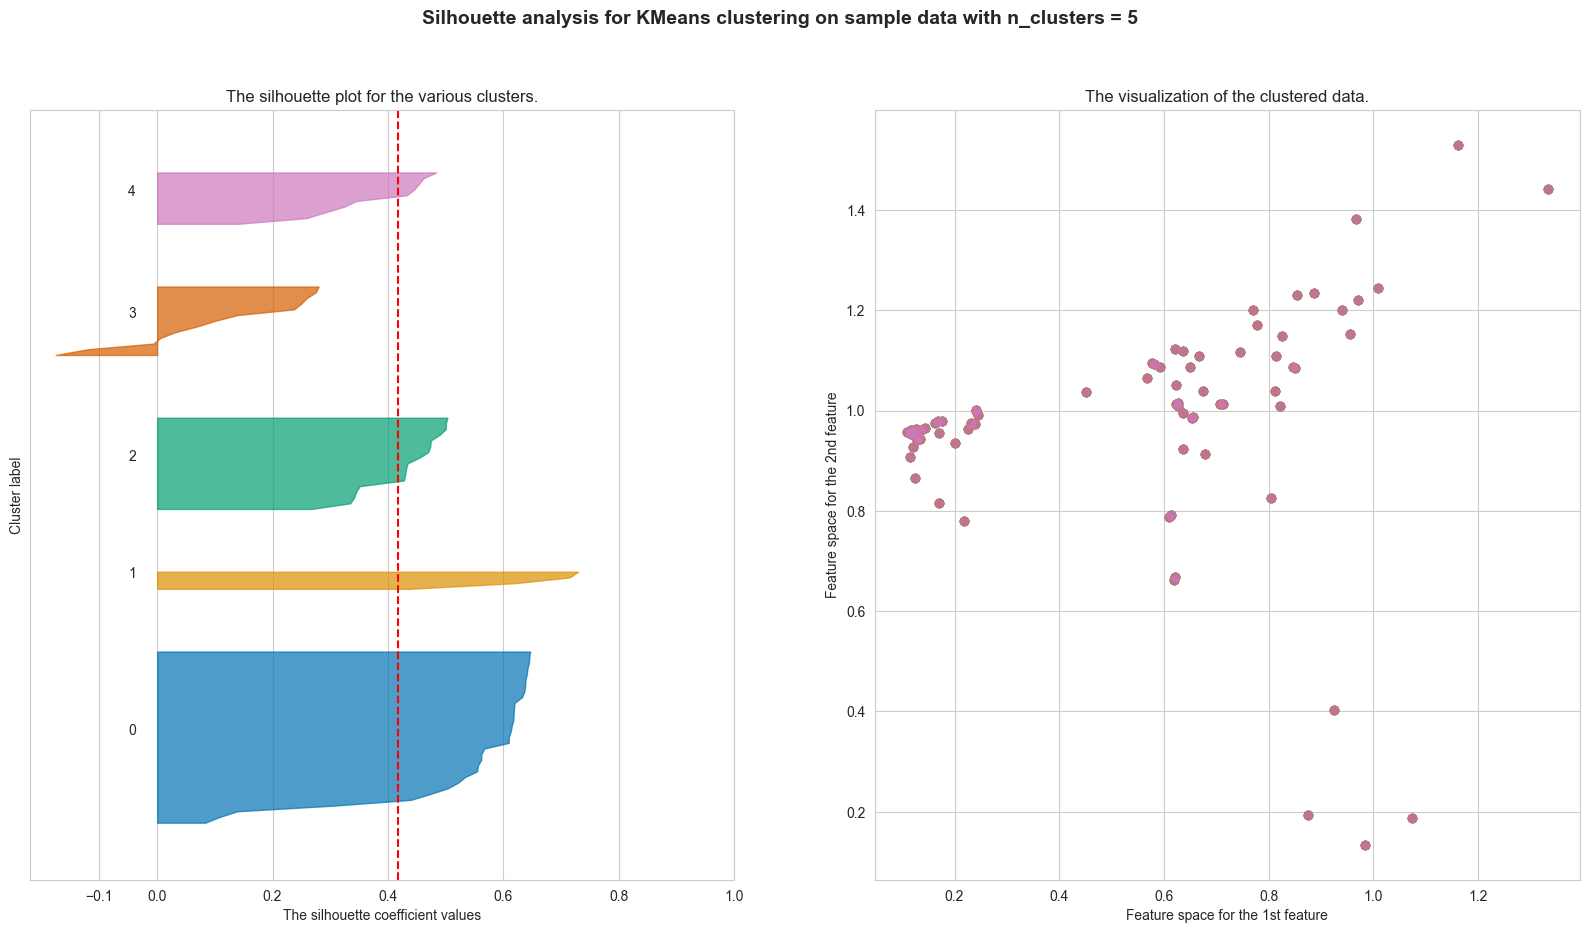

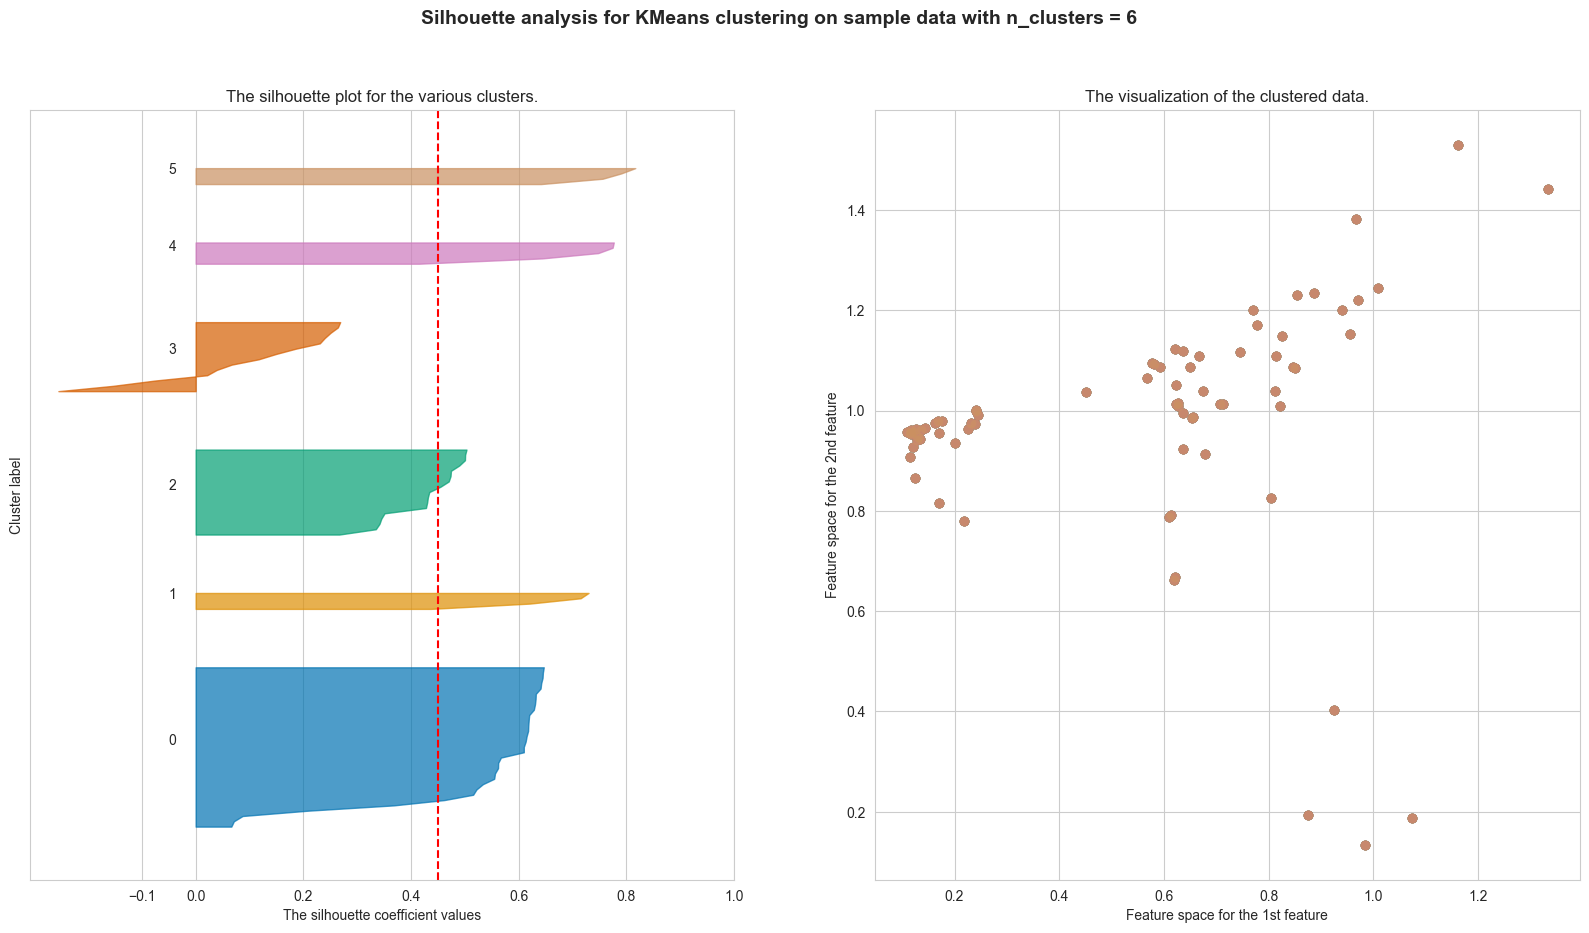

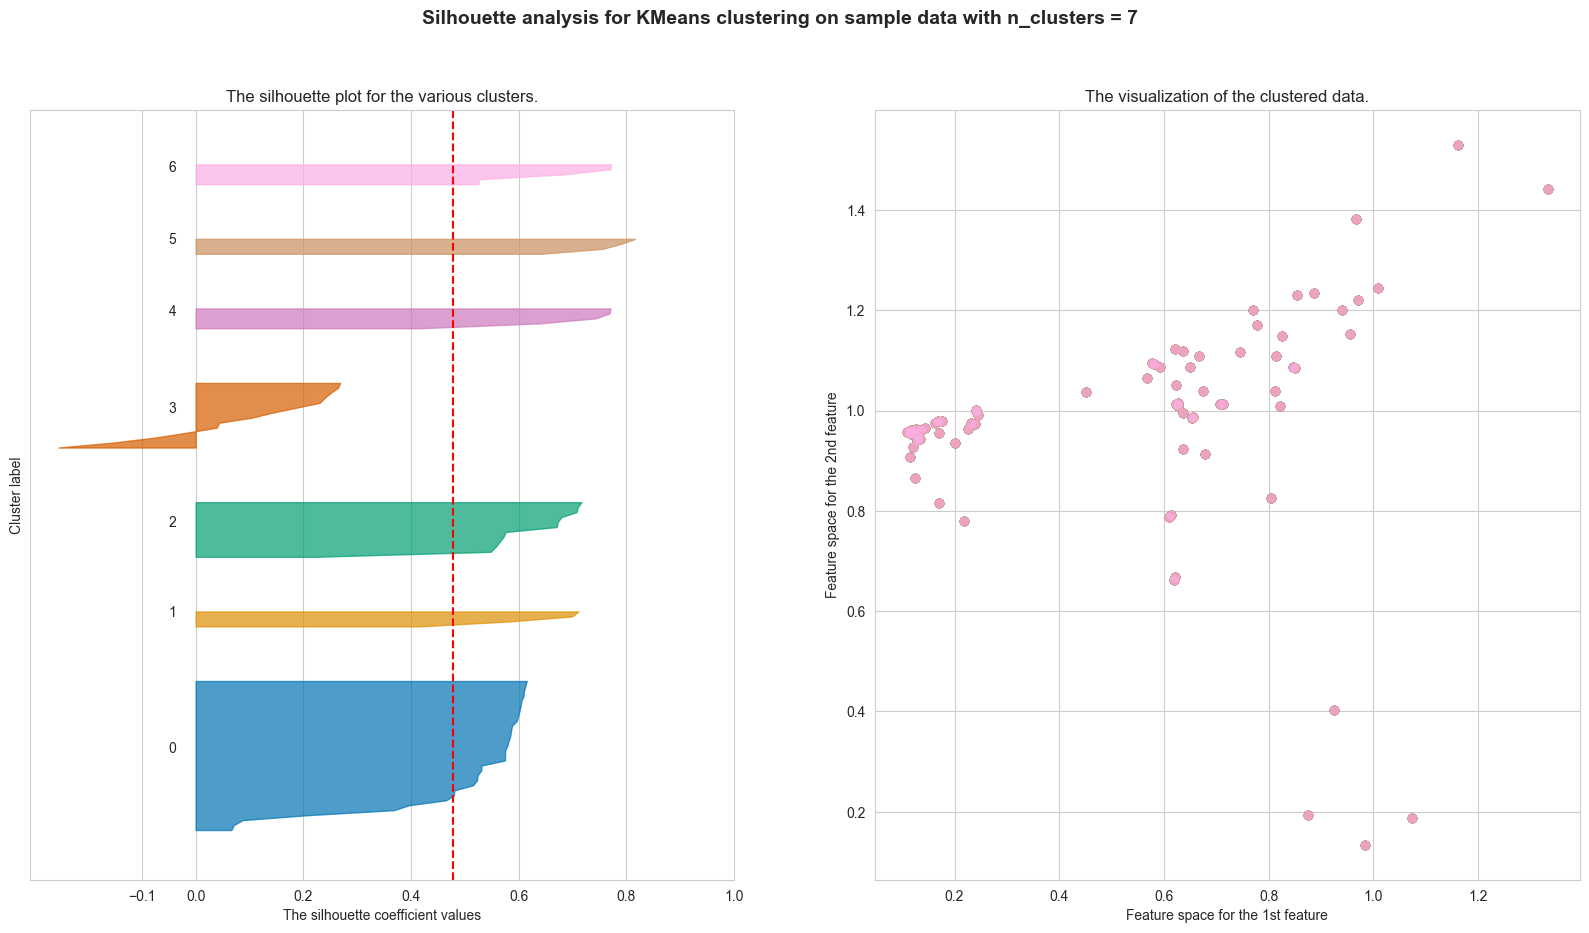

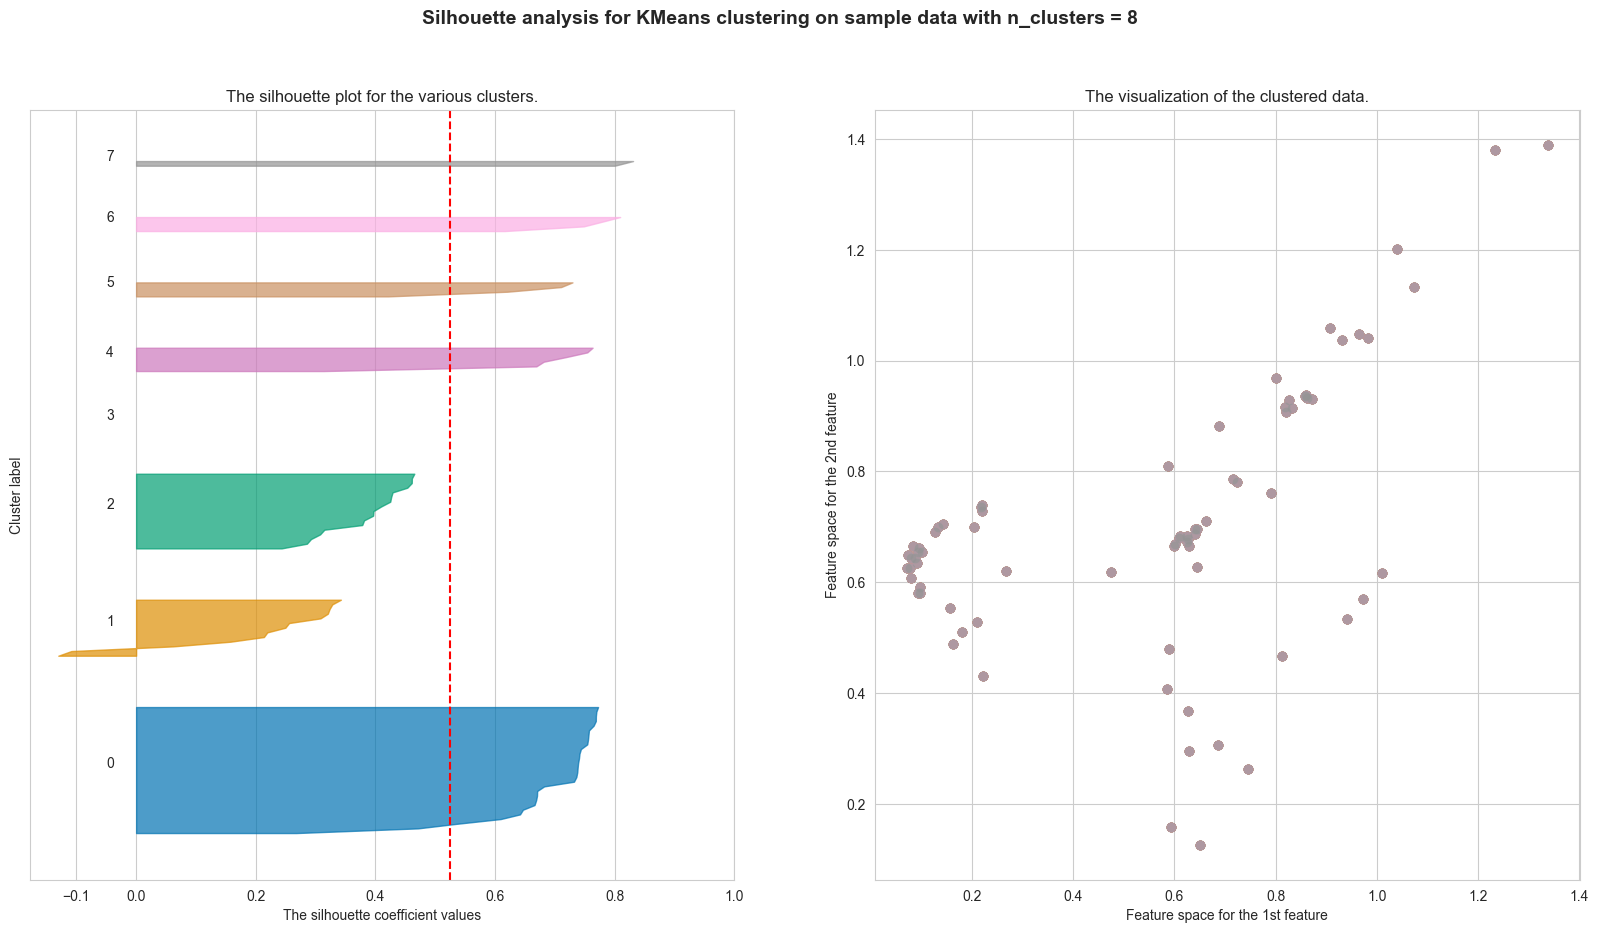

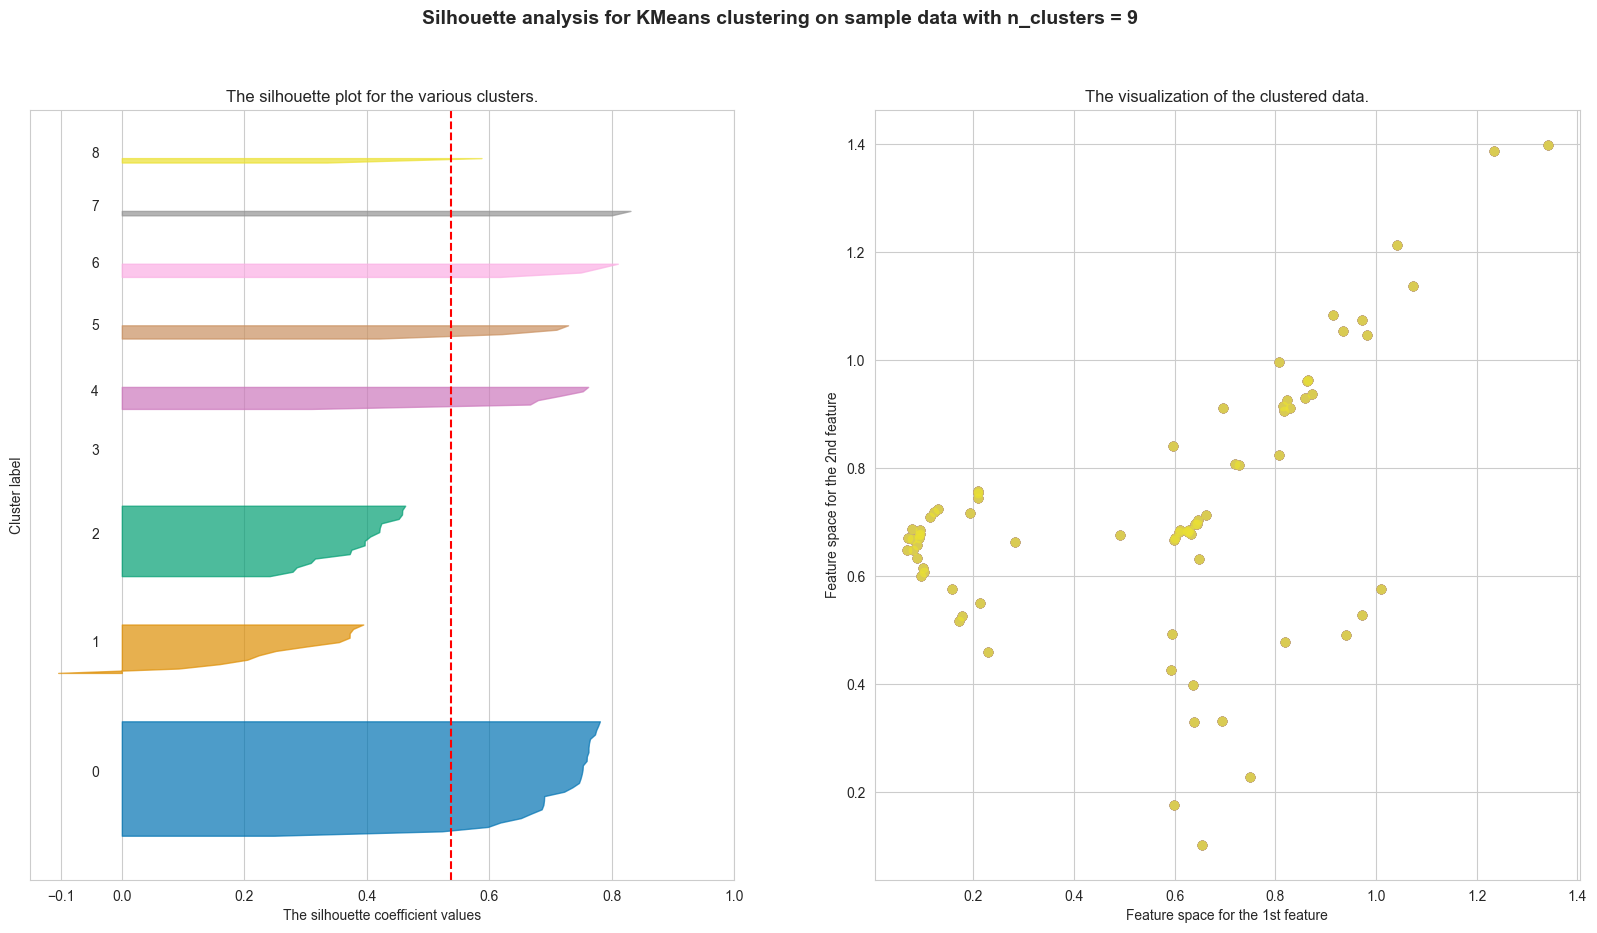

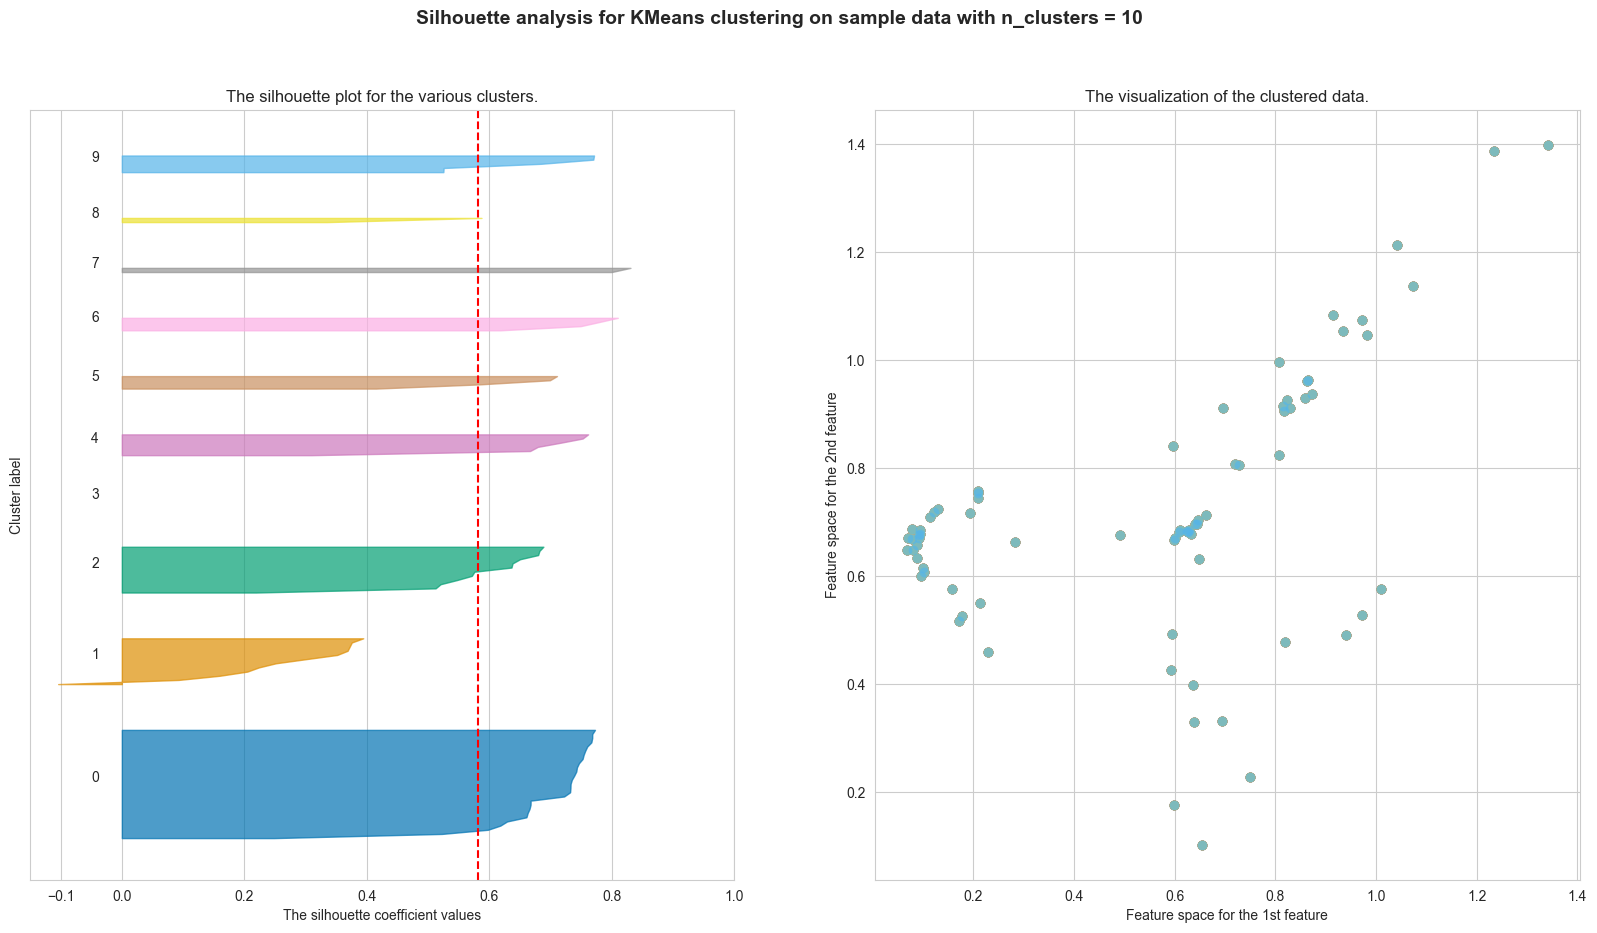

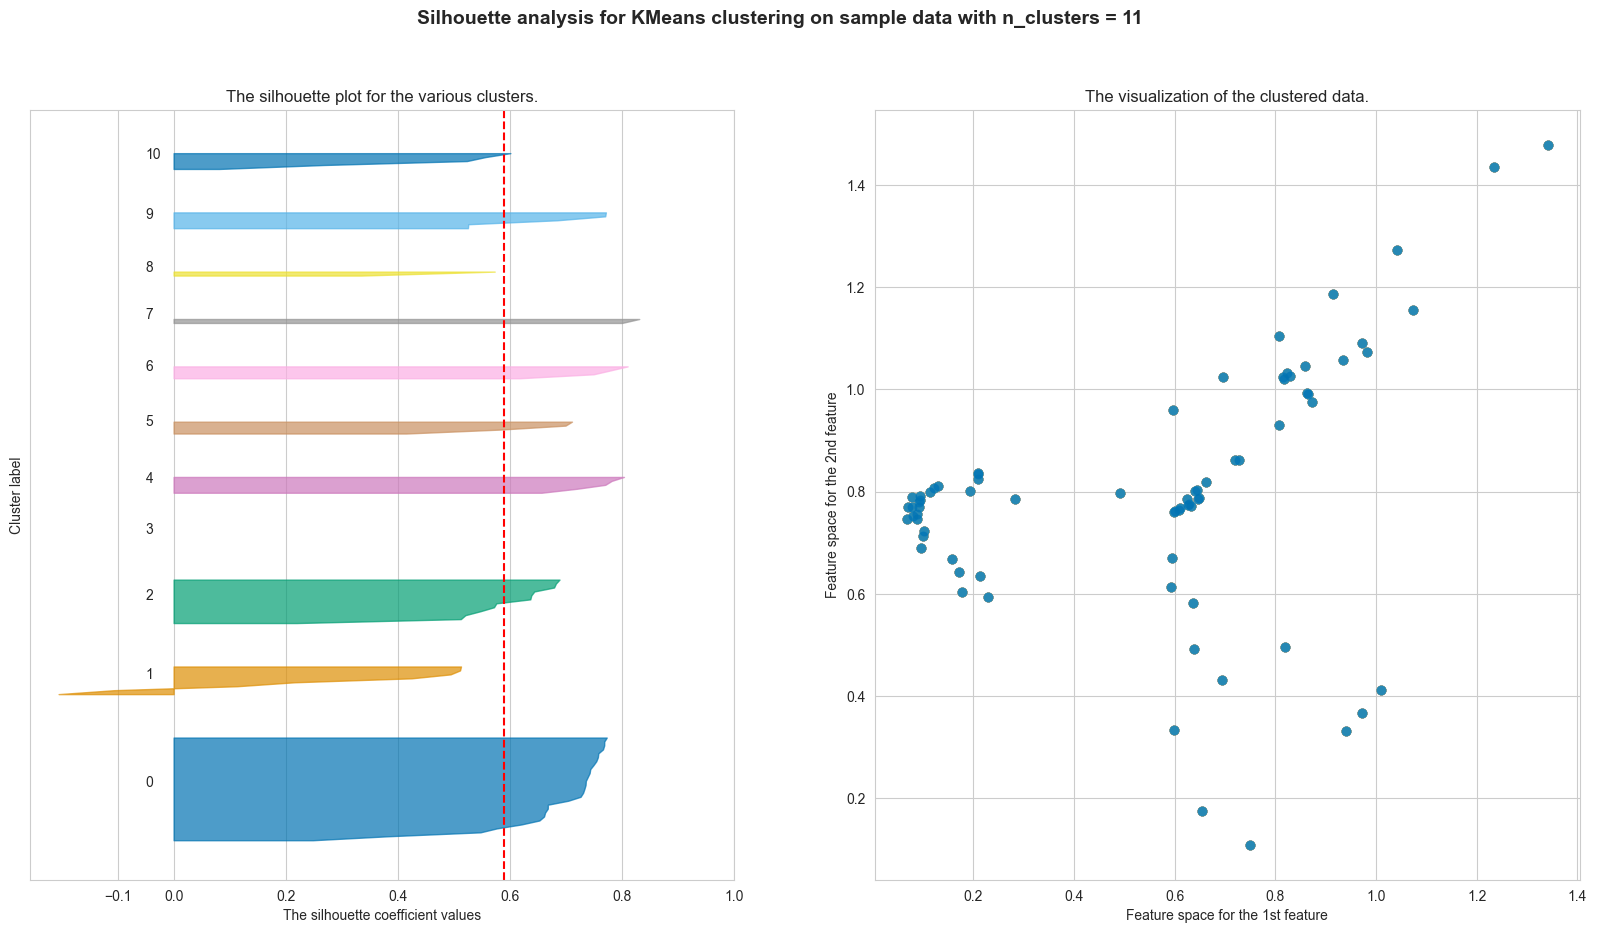

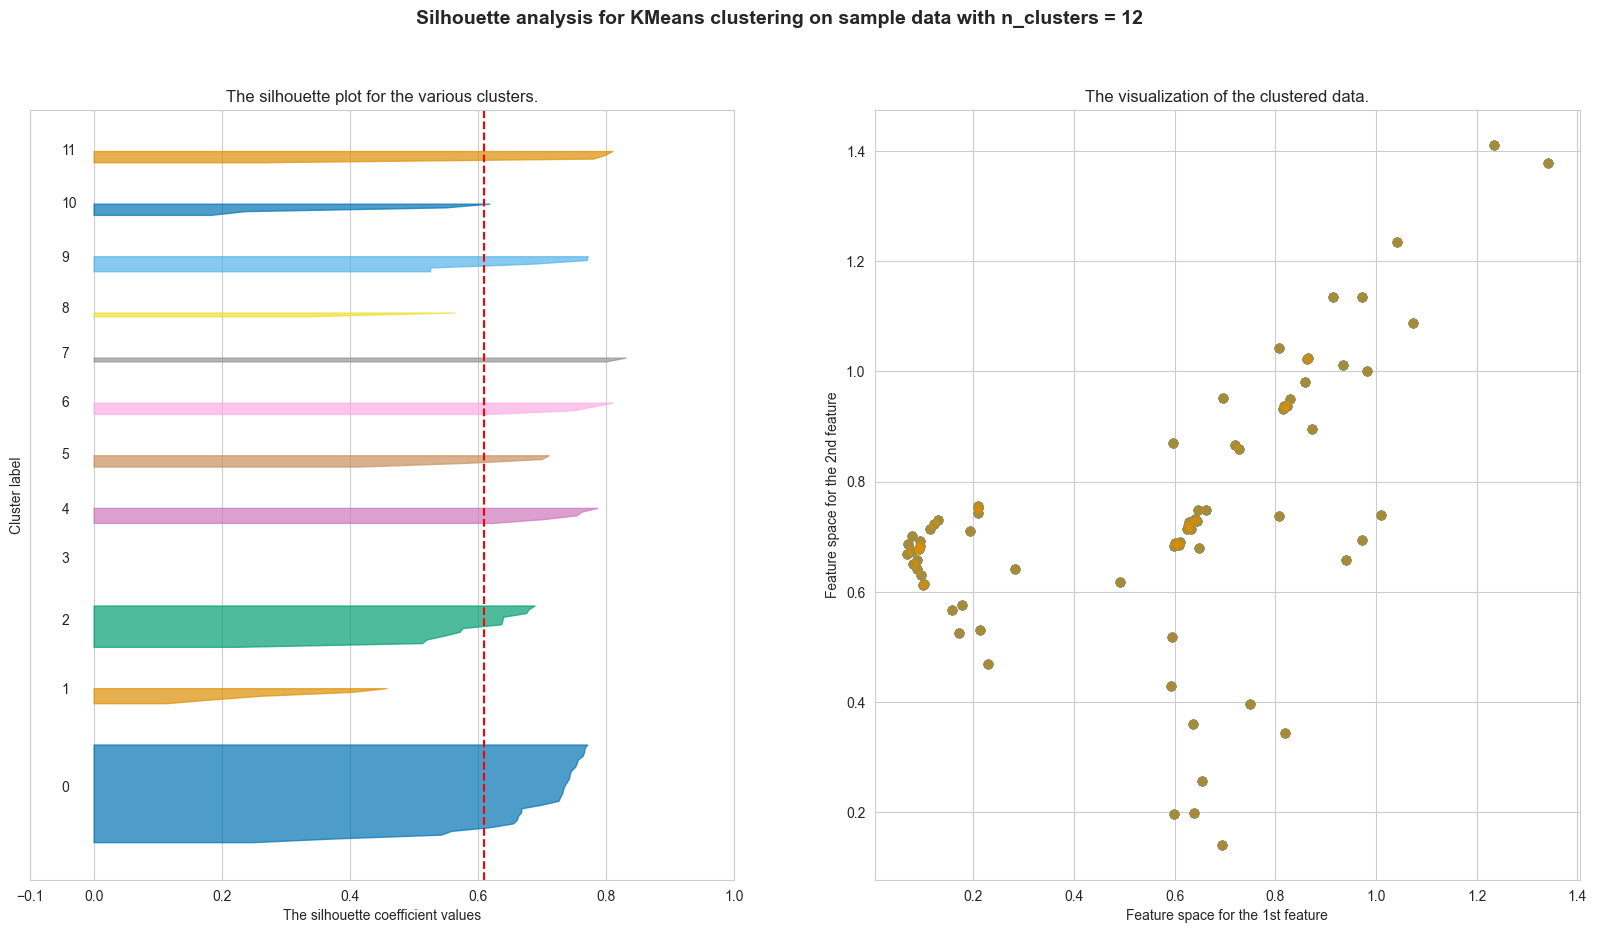

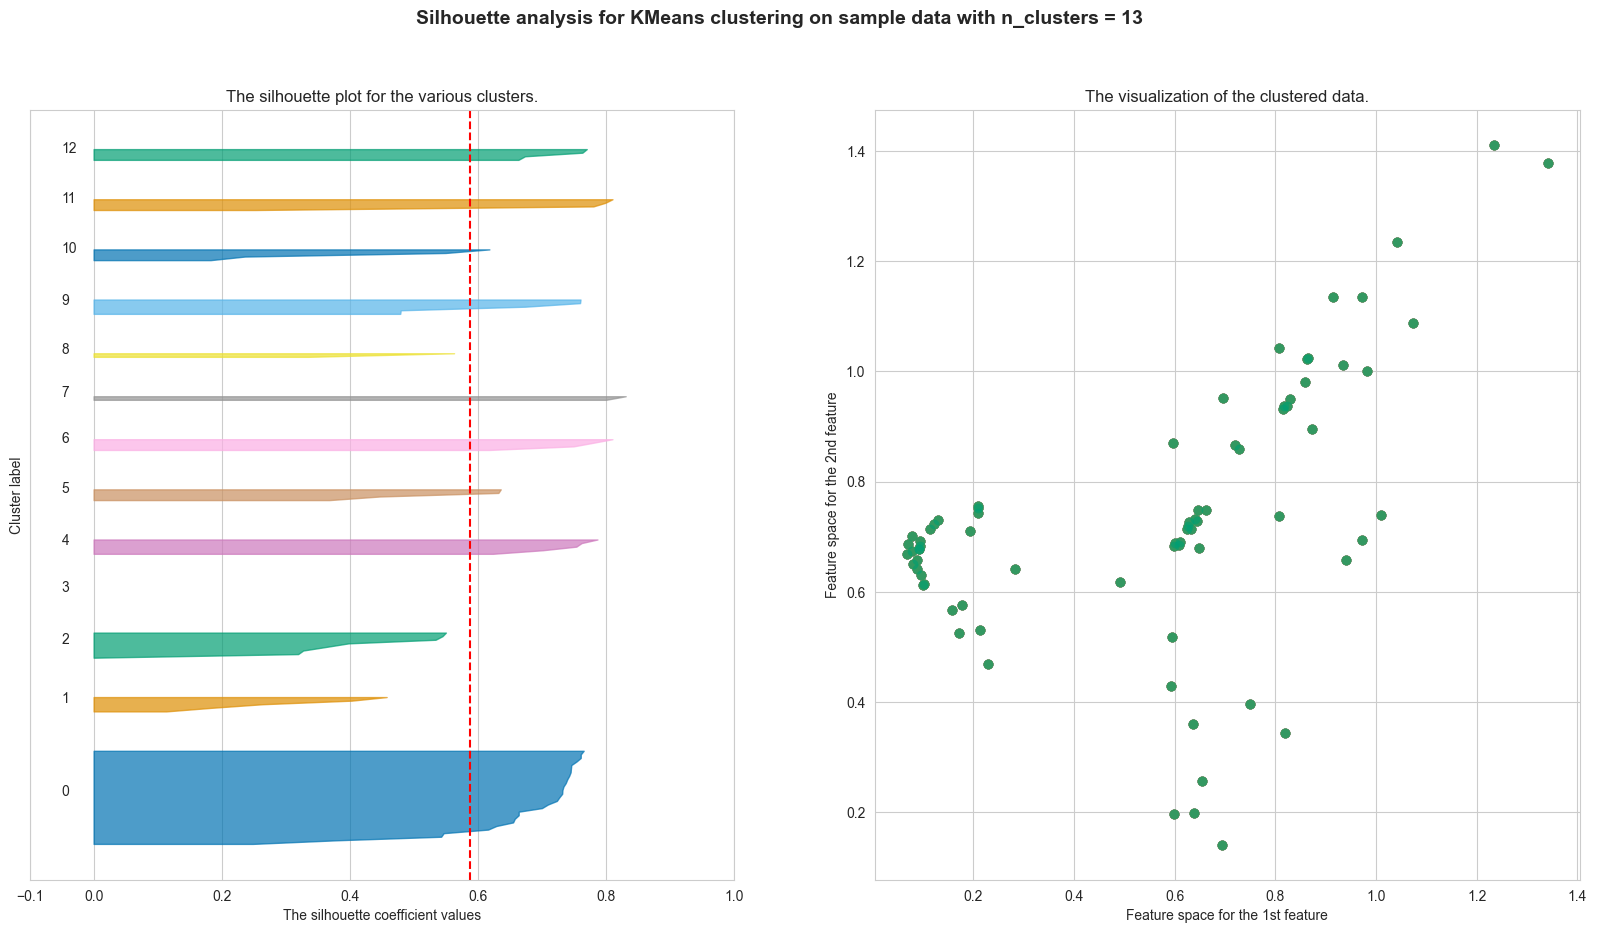

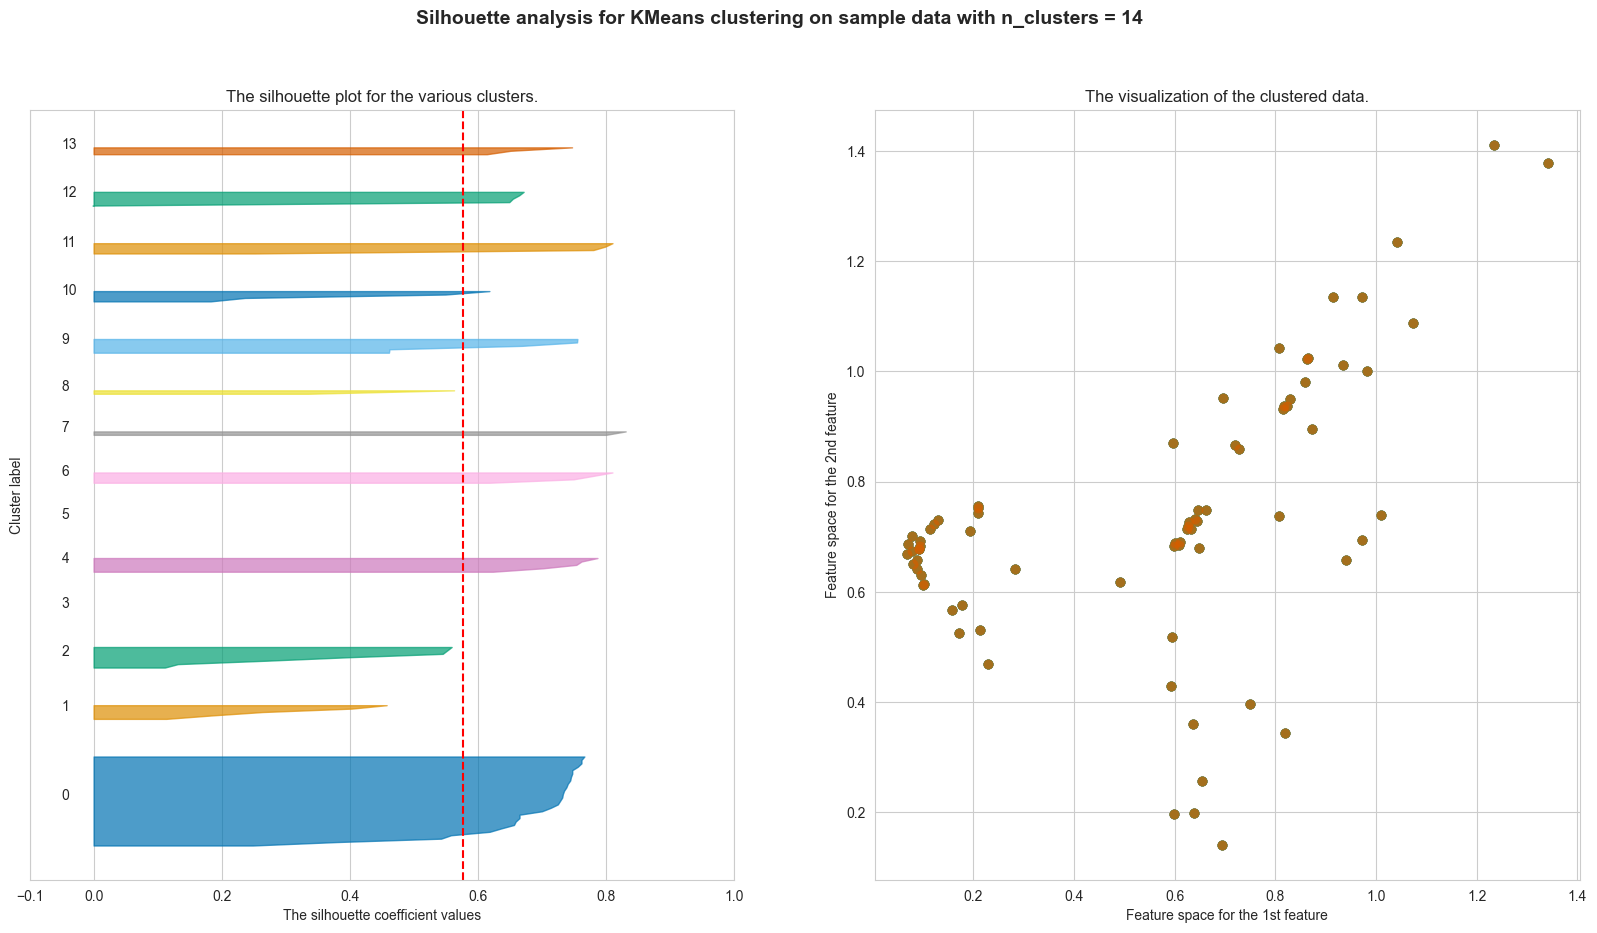

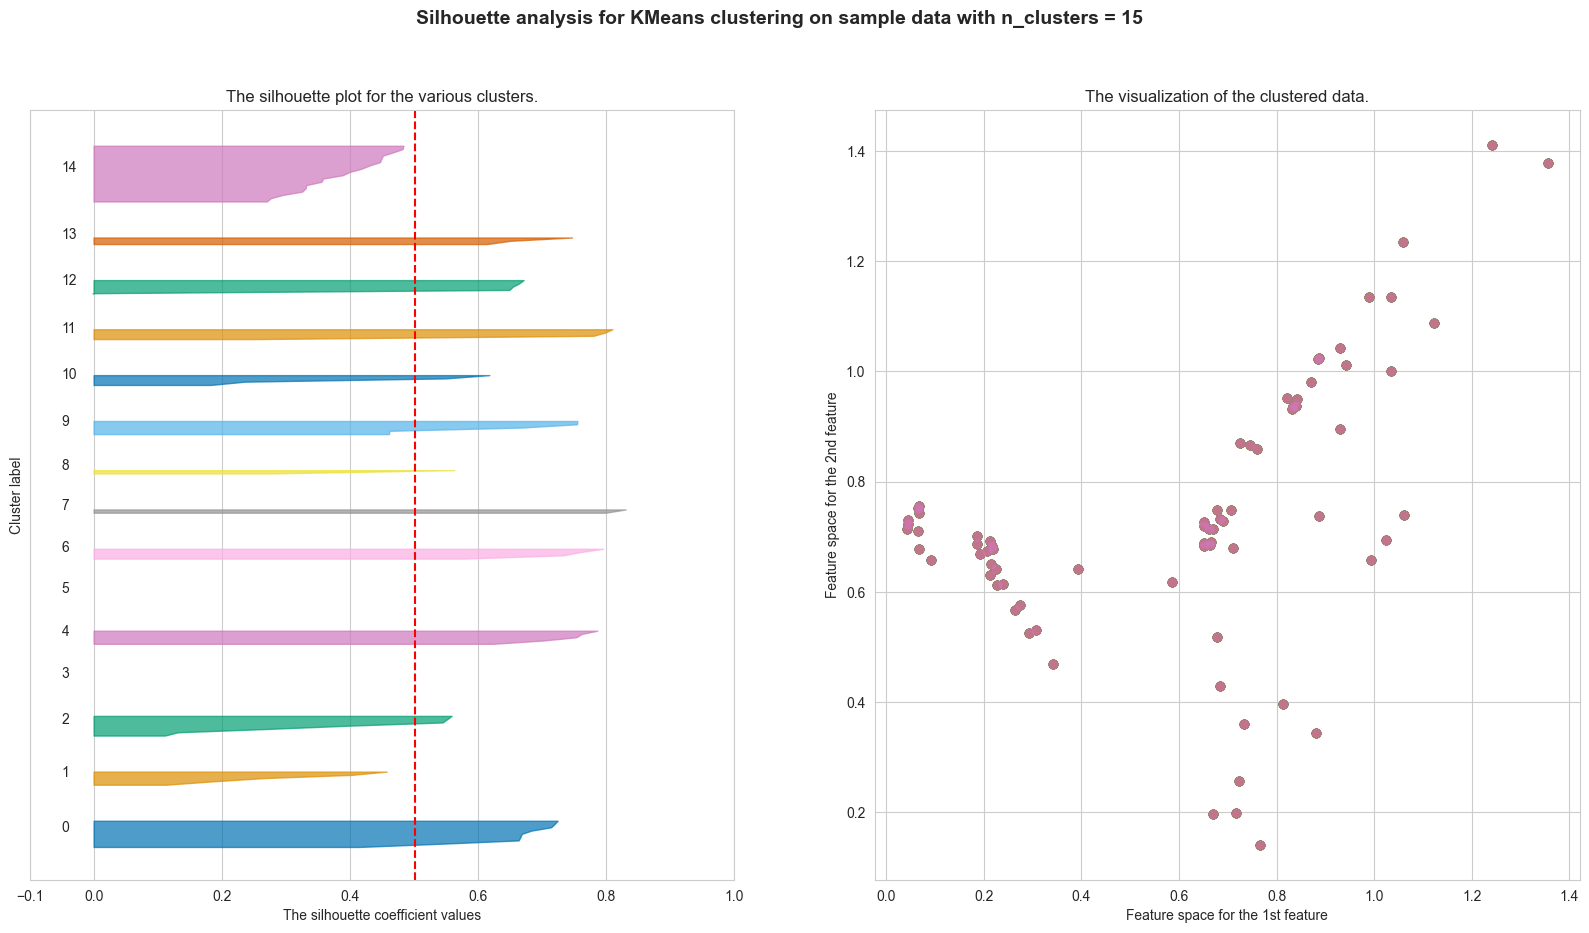

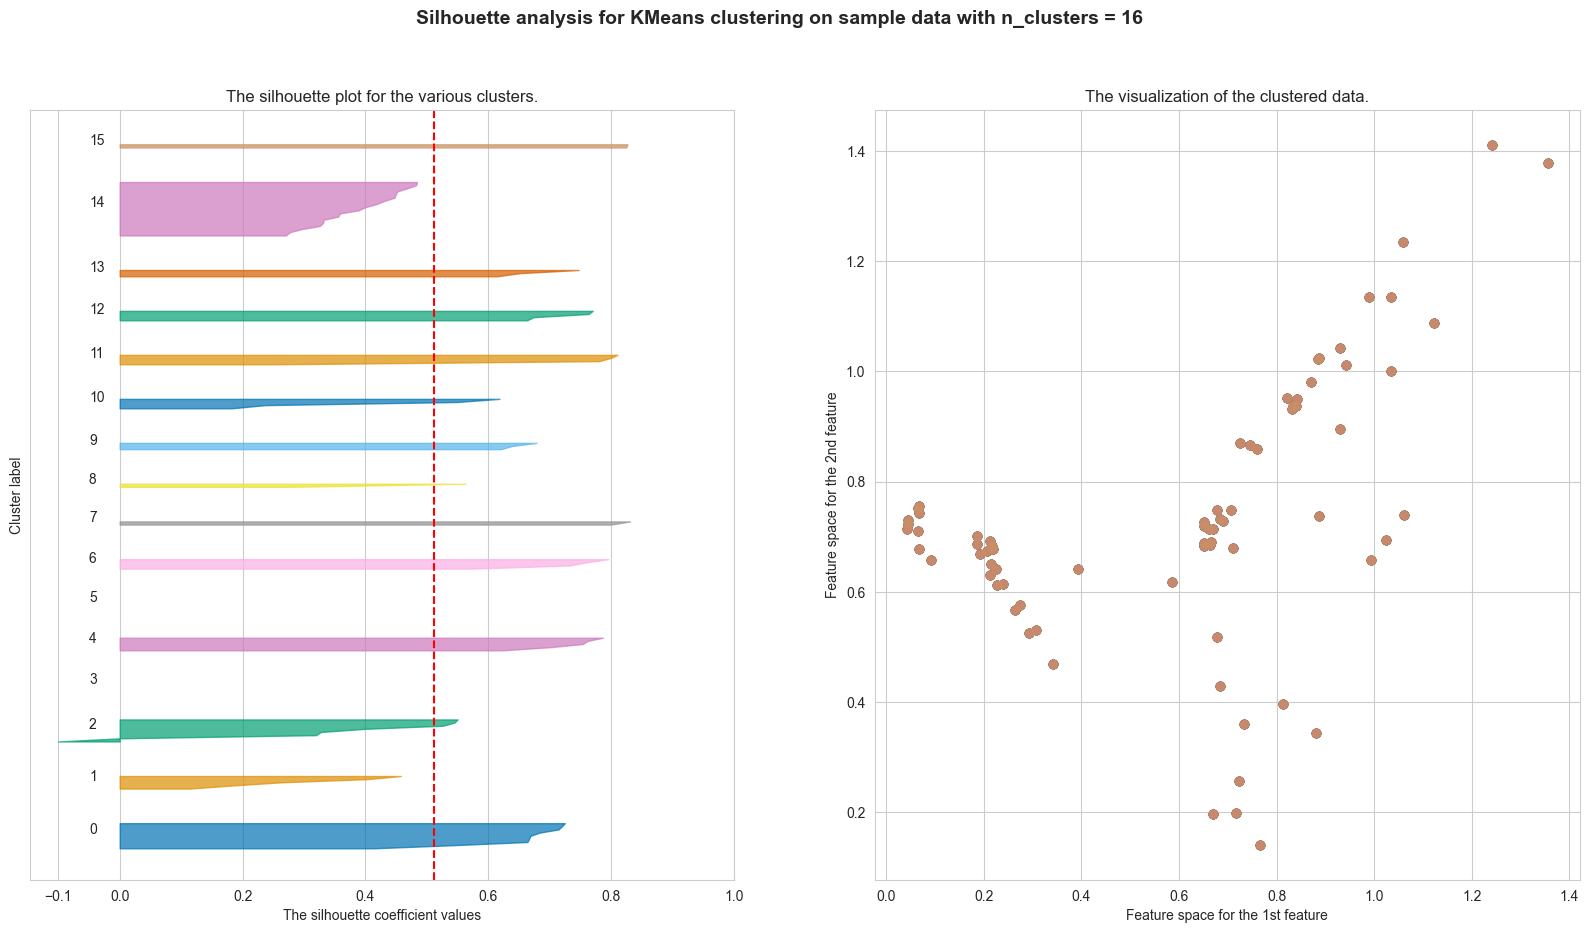

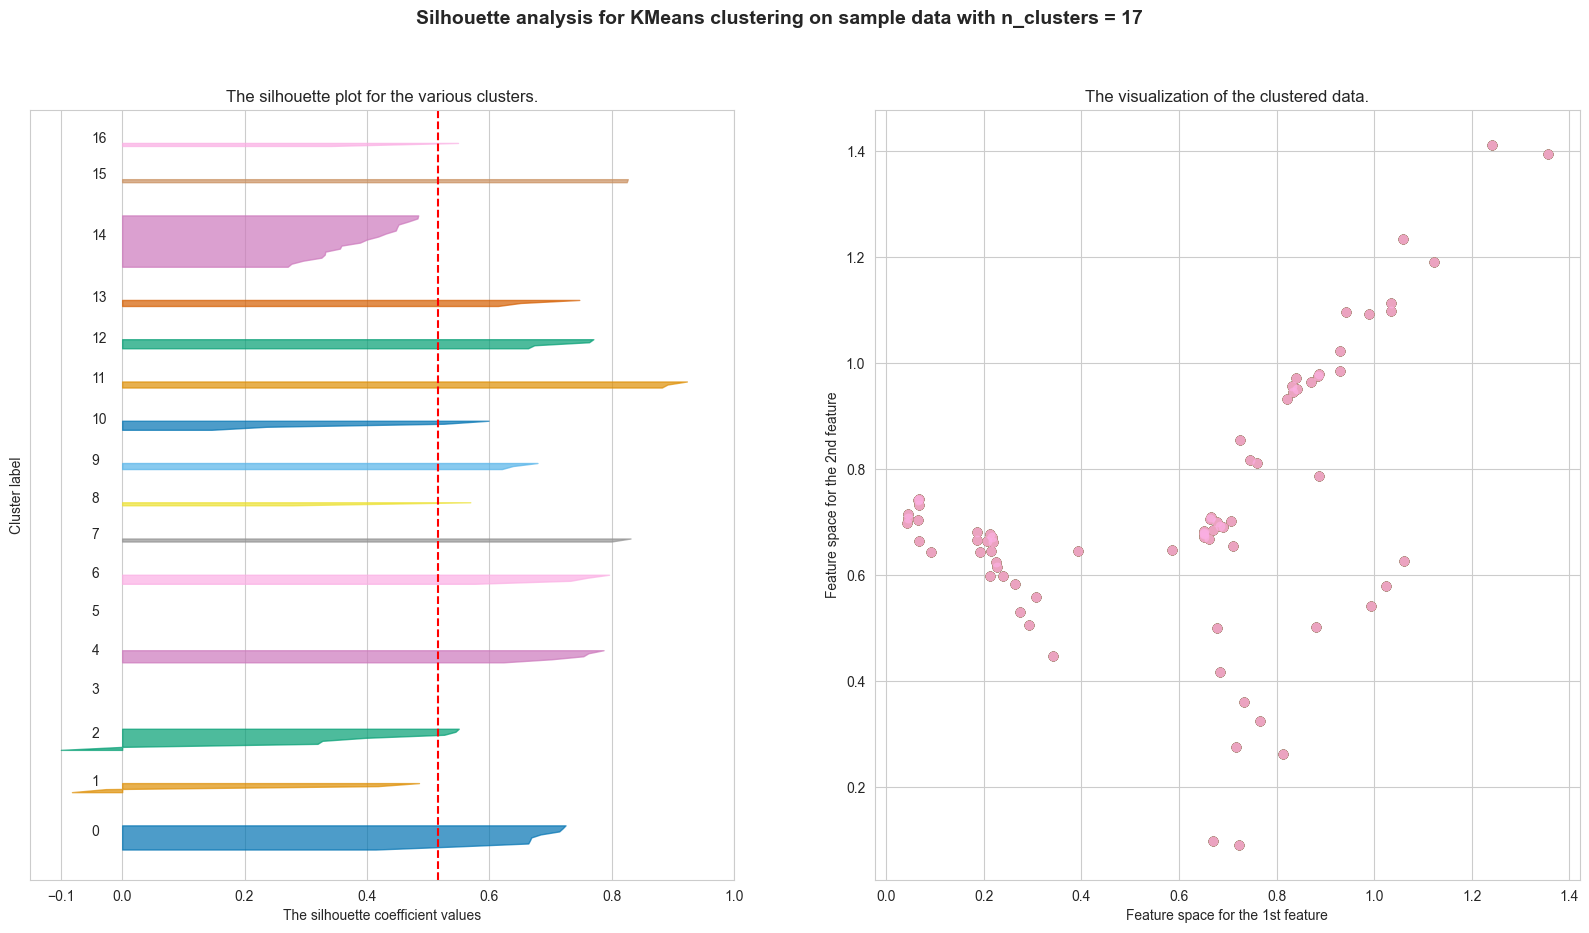

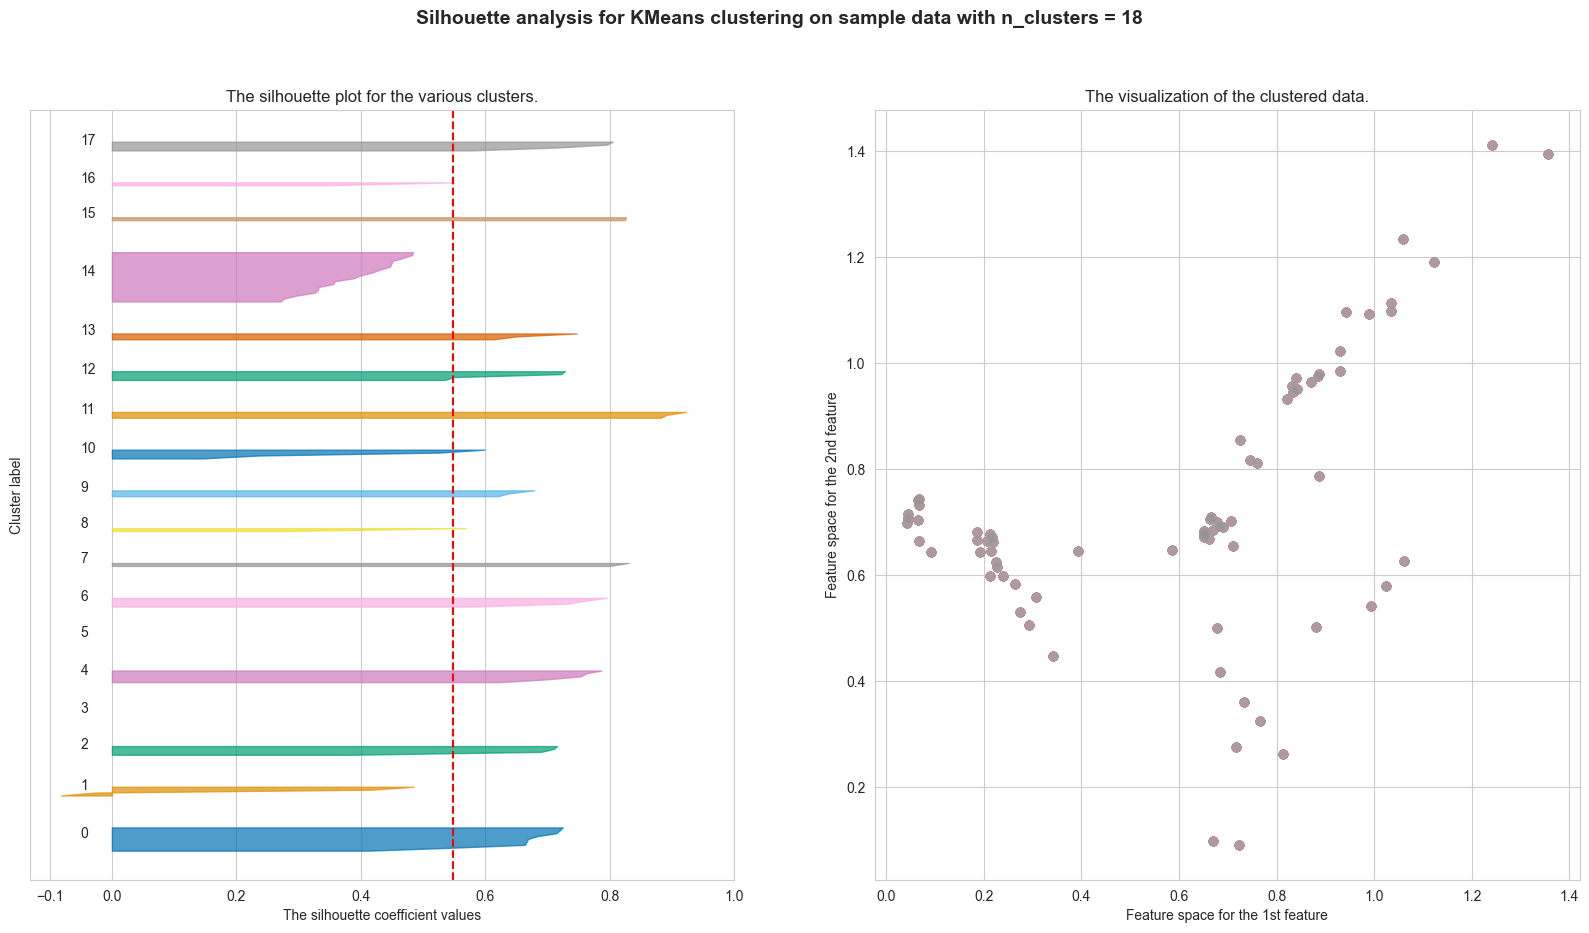

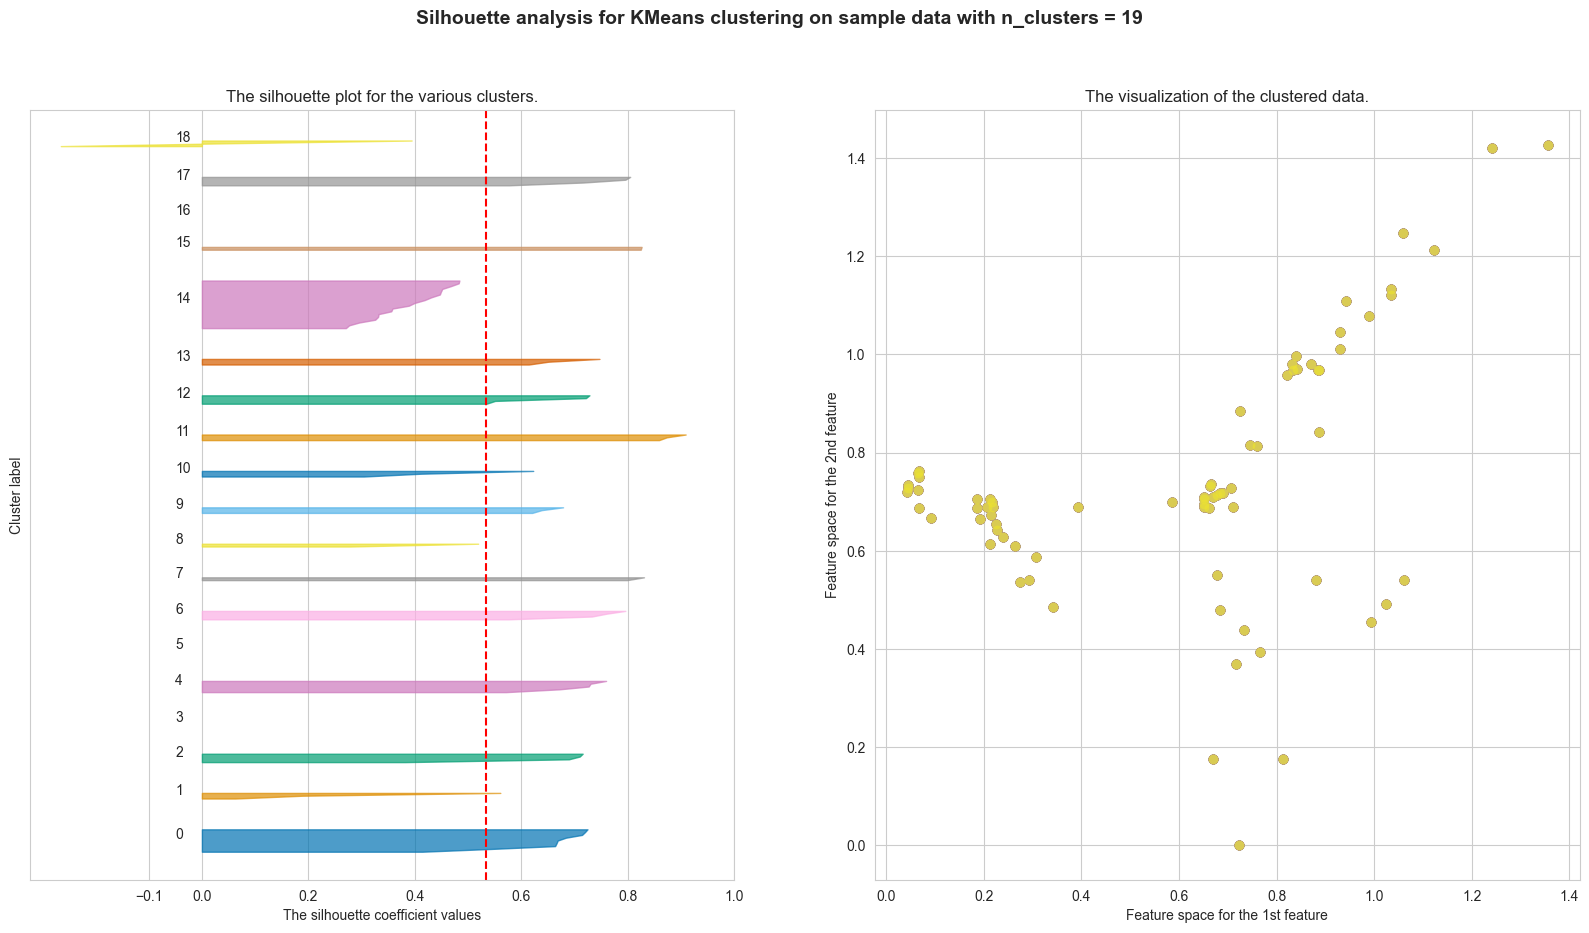

In [30]:
# Source for base code: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

range_n_clusters = range(2, 20)
inertiaList = []
cluster_list = []

for n_clusters in range_n_clusters:
    palette = sns.color_palette("colorblind", n_colors = n_clusters)
    opacity = 1.0
    color = [(*color, opacity) for color in palette]

    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(20, 10)

    # The 1st subplot is the silhouette plot
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(normalized) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value
    clusterer = KMeans(n_clusters=n_clusters, random_state=seed, max_iter=10000)
    #print(clusterer.get_params())

    cluster_labels = clusterer.fit_predict(normalized)
    cluster_transform = clusterer.fit_transform(normalized)
    #cluster_list.append(cluster_labels)
    #normalized["labels"] = cluster_labels
    #print(normalized["labels"].unique())

    # Store inertia values for elbow method
    inertia = clusterer.fit(normalized).inertia_
    #print(inertia)
    inertiaList.append(inertia)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(normalized, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(normalized, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color[i],
            edgecolor=color[i],
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

        ax2.scatter(cluster_transform[:, 0], cluster_transform[:, 1], marker="o", s=50, lw=0, alpha=0.7,color=color[i], edgecolor="k")


    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])



    # 2nd Plot showing the actual clusters formed
    #colors = cm.viridis(cluster_labels.astype(float) / n_clusters)

    # ax2.scatter(
    #      cluster_transform[:, 0], cluster_transform[:, 1], marker=".", s=50, lw=0, alpha=0.7,color=color[0], edgecolor="k"
    #  )
    #radviz(dataframe = normalized, ax = ax2, labels = normalized.columns[-1], colors = color)

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )
    # Save the plot as a png file
    # filepath = os.path.join("../results/", f"Radviz_nClusters_{n_clusters}.png")
    # plt.savefig(filepath, bbox_inches = "tight")

plt.show()

In [ ]:
# Create plot for elbow method
plt.plot(range_n_clusters, inertiaList, marker = "o")

# Style plot
plt.title("Elbow Method")
plt.xlabel("n_clusters")
plt.ylabel("Inertia")
plt.grid(True)

# Display plot
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.48995917404271744
For n_clusters = 3 The average silhouette_score is : 0.557148778781574
For n_clusters = 4 The average silhouette_score is : 0.5875114400686788
For n_clusters = 5 The average silhouette_score is : 0.6088547177721992
For n_clusters = 6 The average silhouette_score is : 0.6481858376211438
For n_clusters = 7 The average silhouette_score is : 0.6533513838058636
For n_clusters = 8 The average silhouette_score is : 0.7152644937923652
For n_clusters = 9 The average silhouette_score is : 0.754543476352855
For n_clusters = 10 The average silhouette_score is : 0.7590822106322405


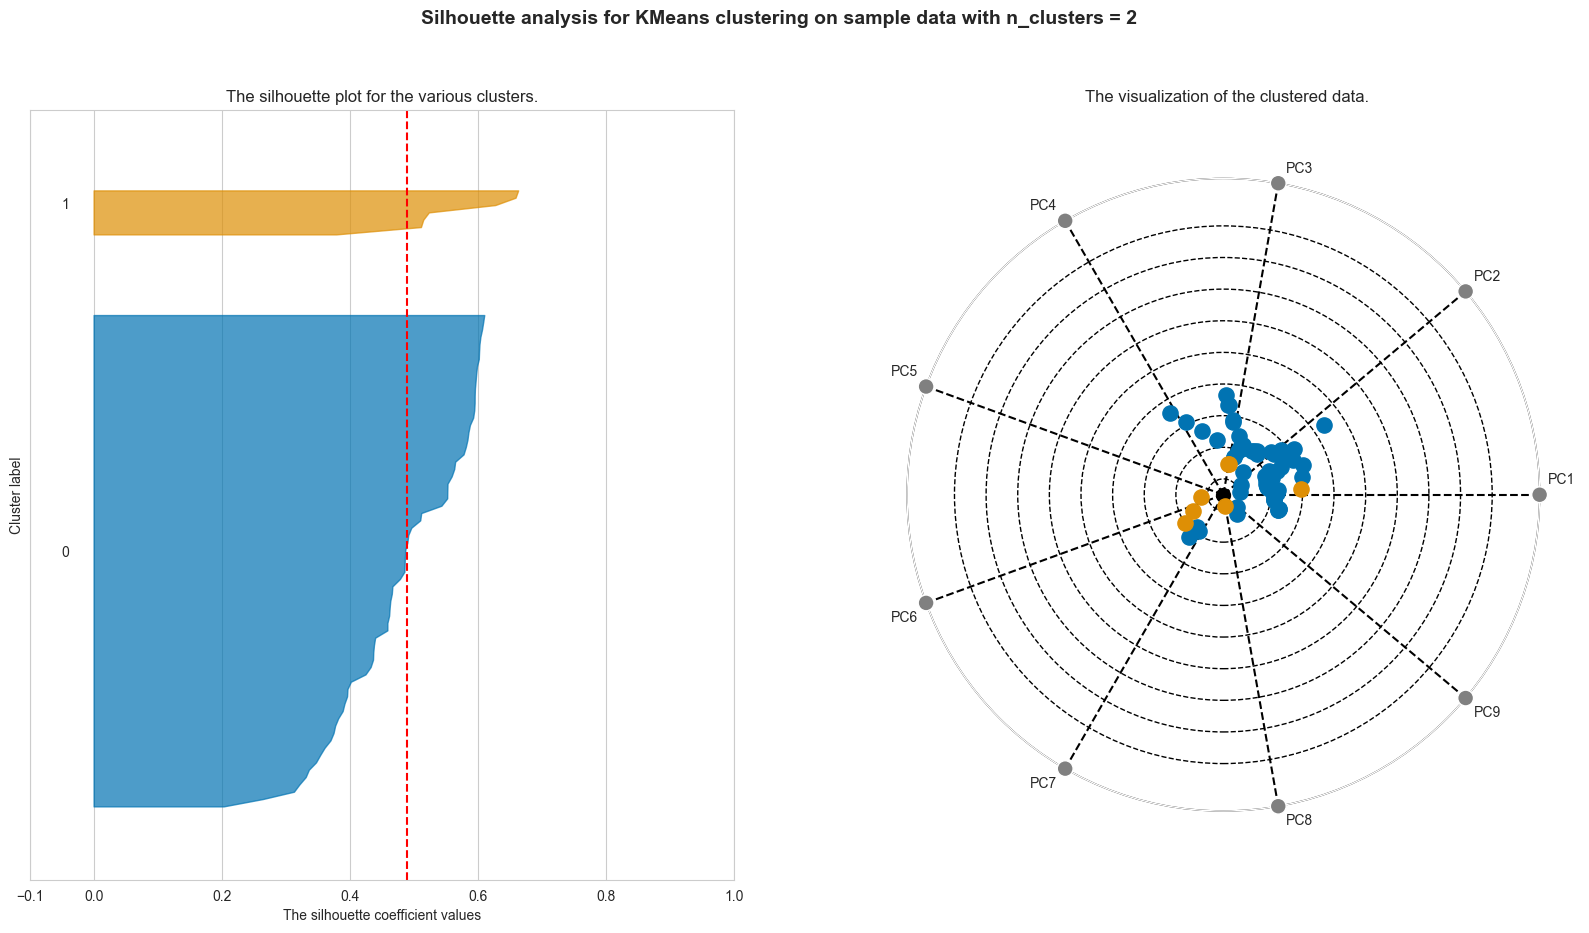

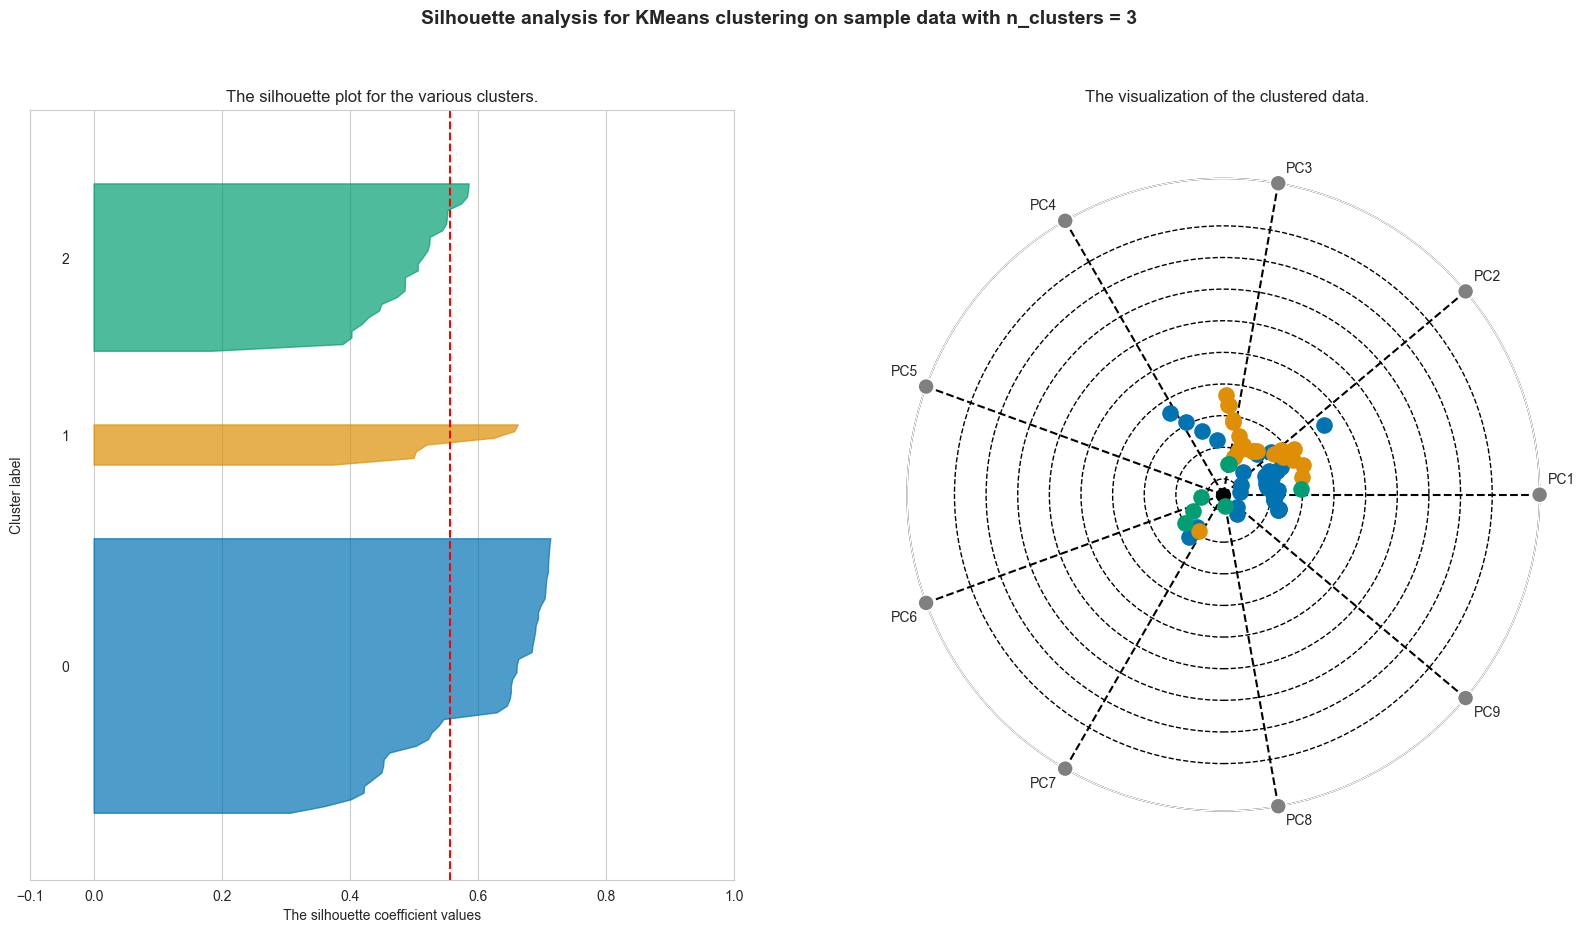

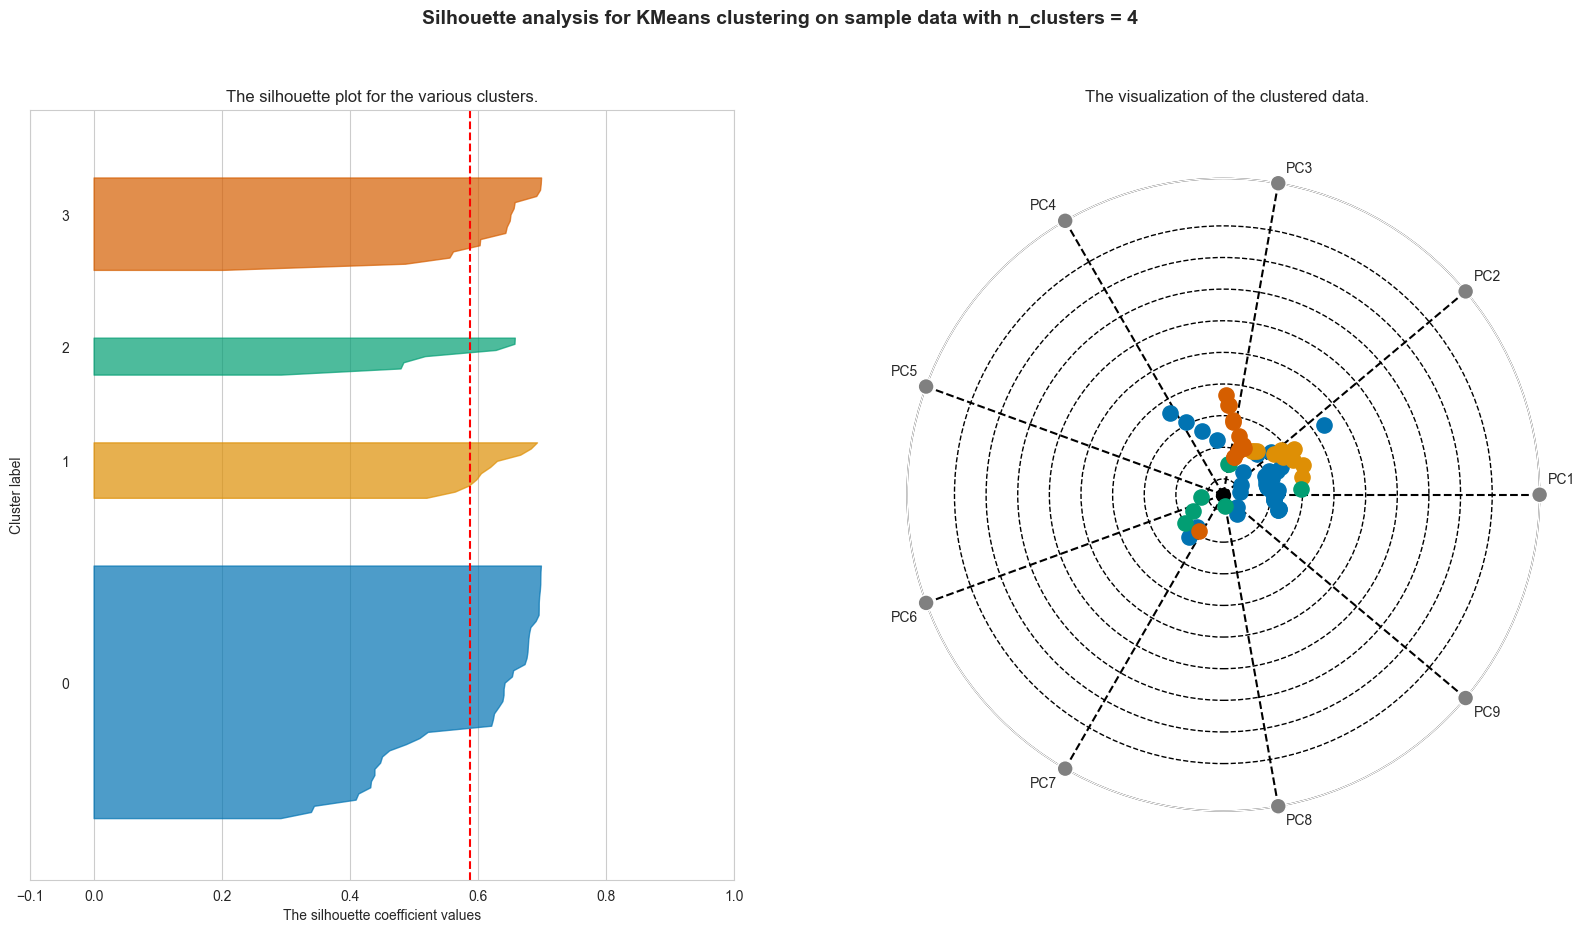

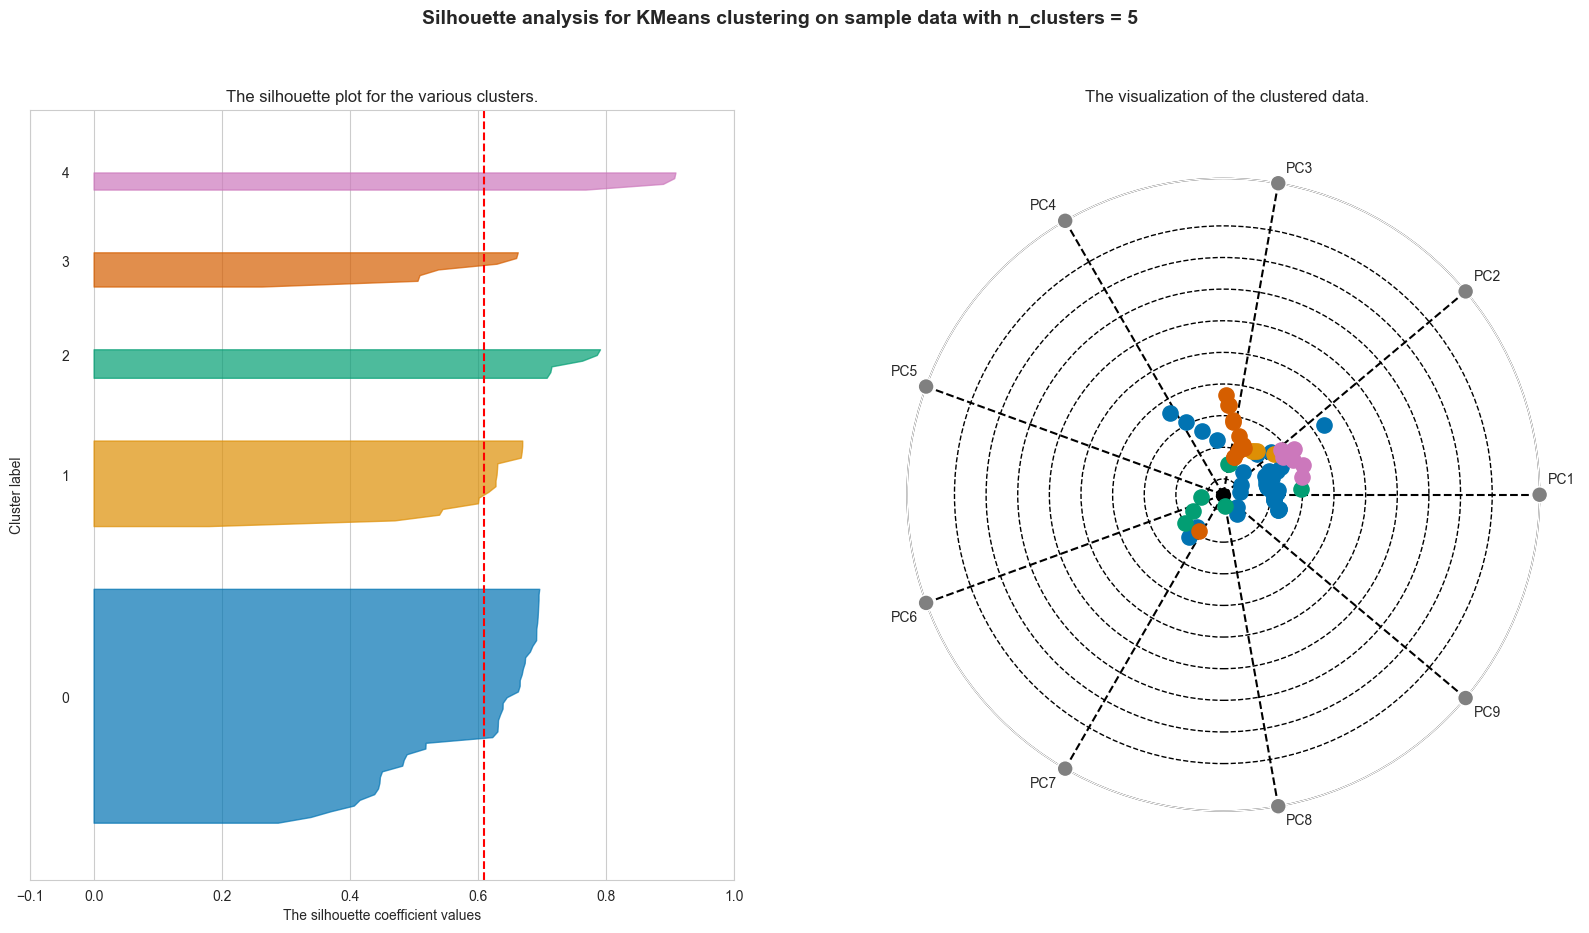

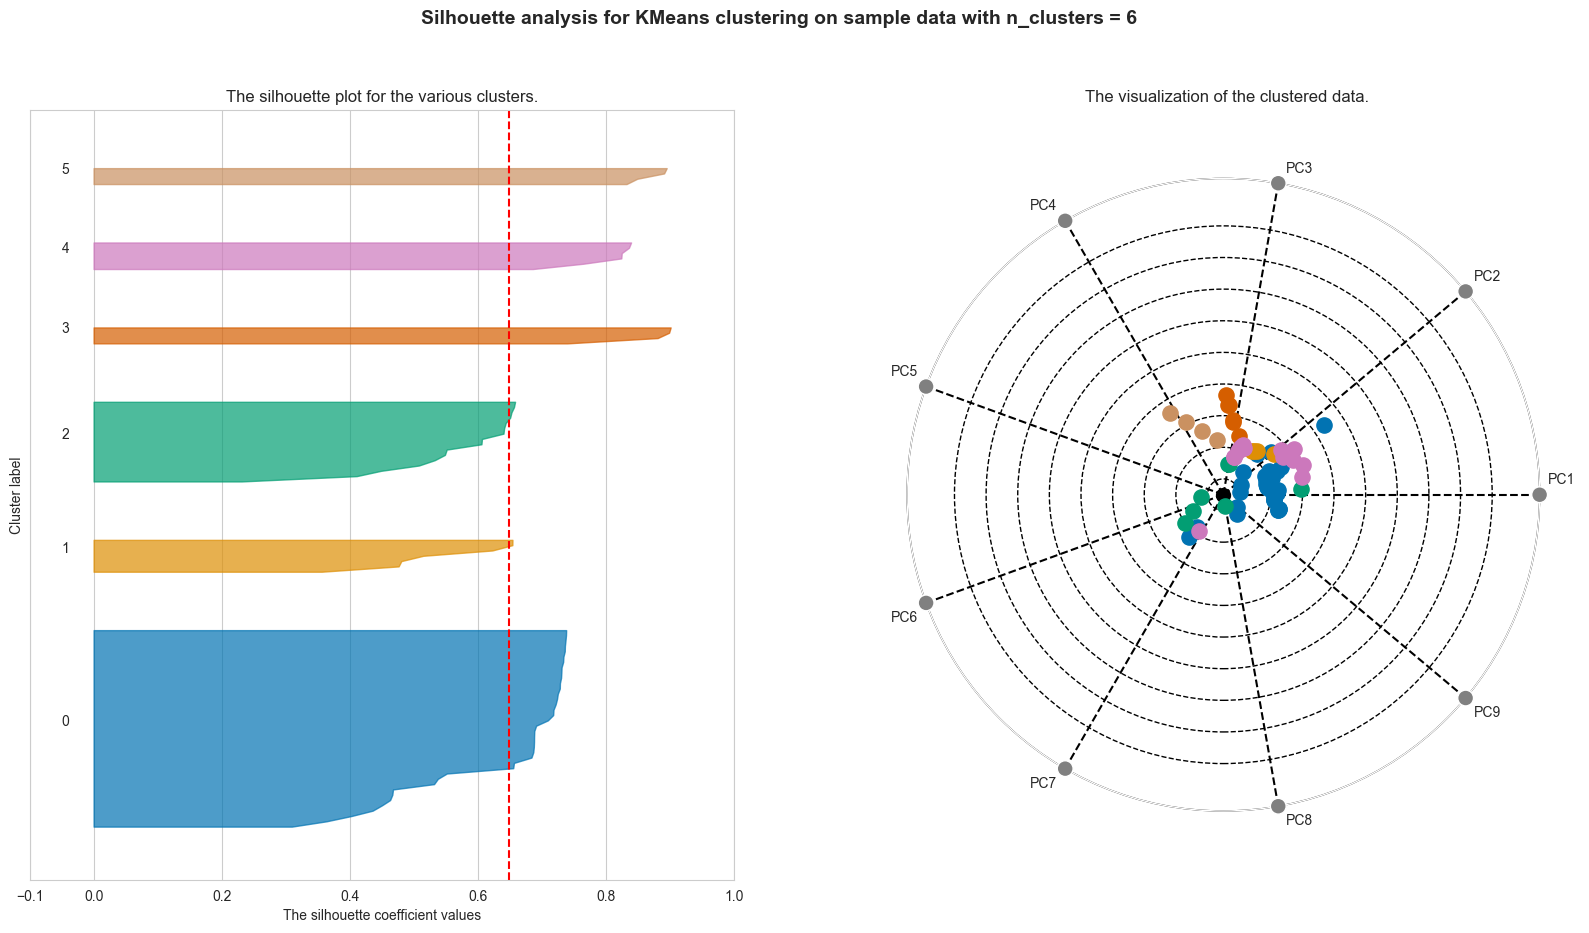

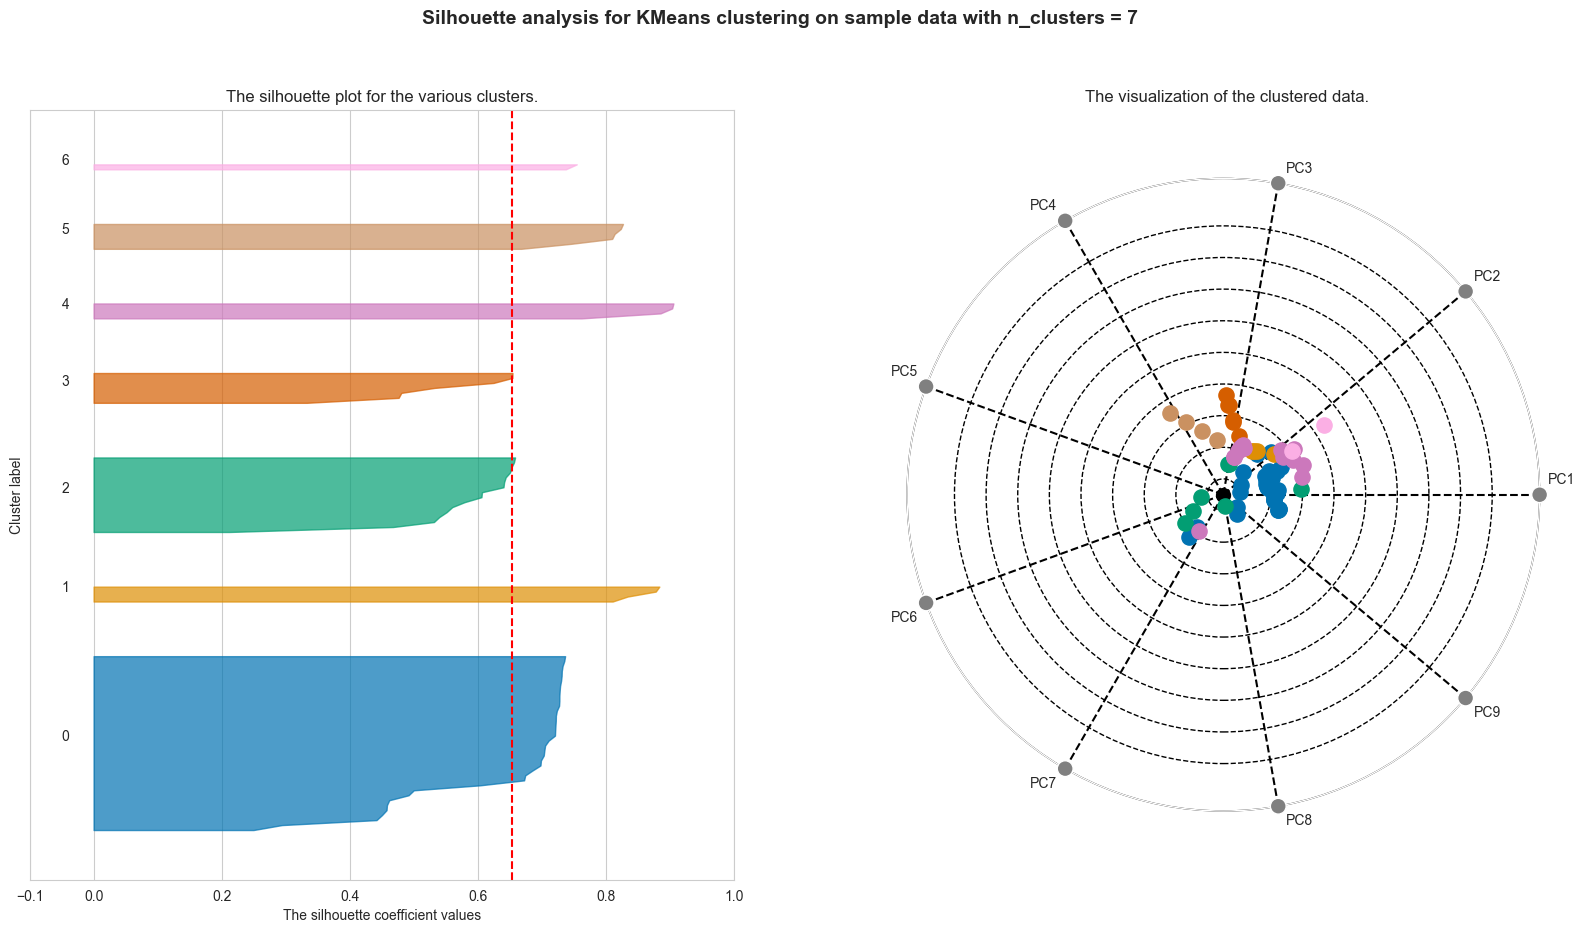

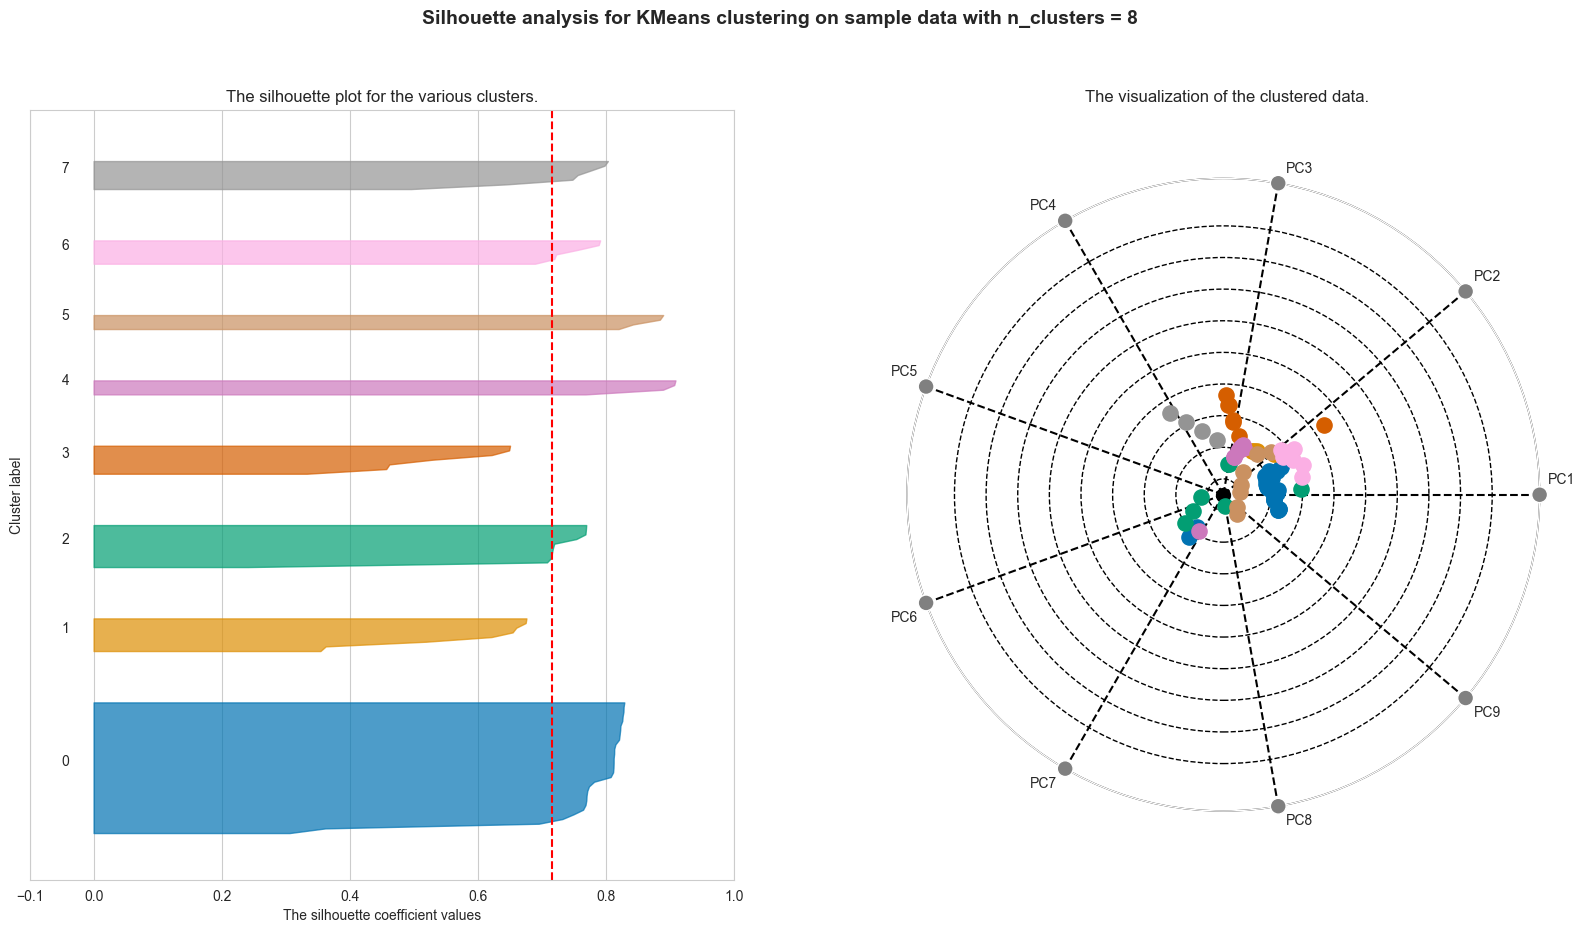

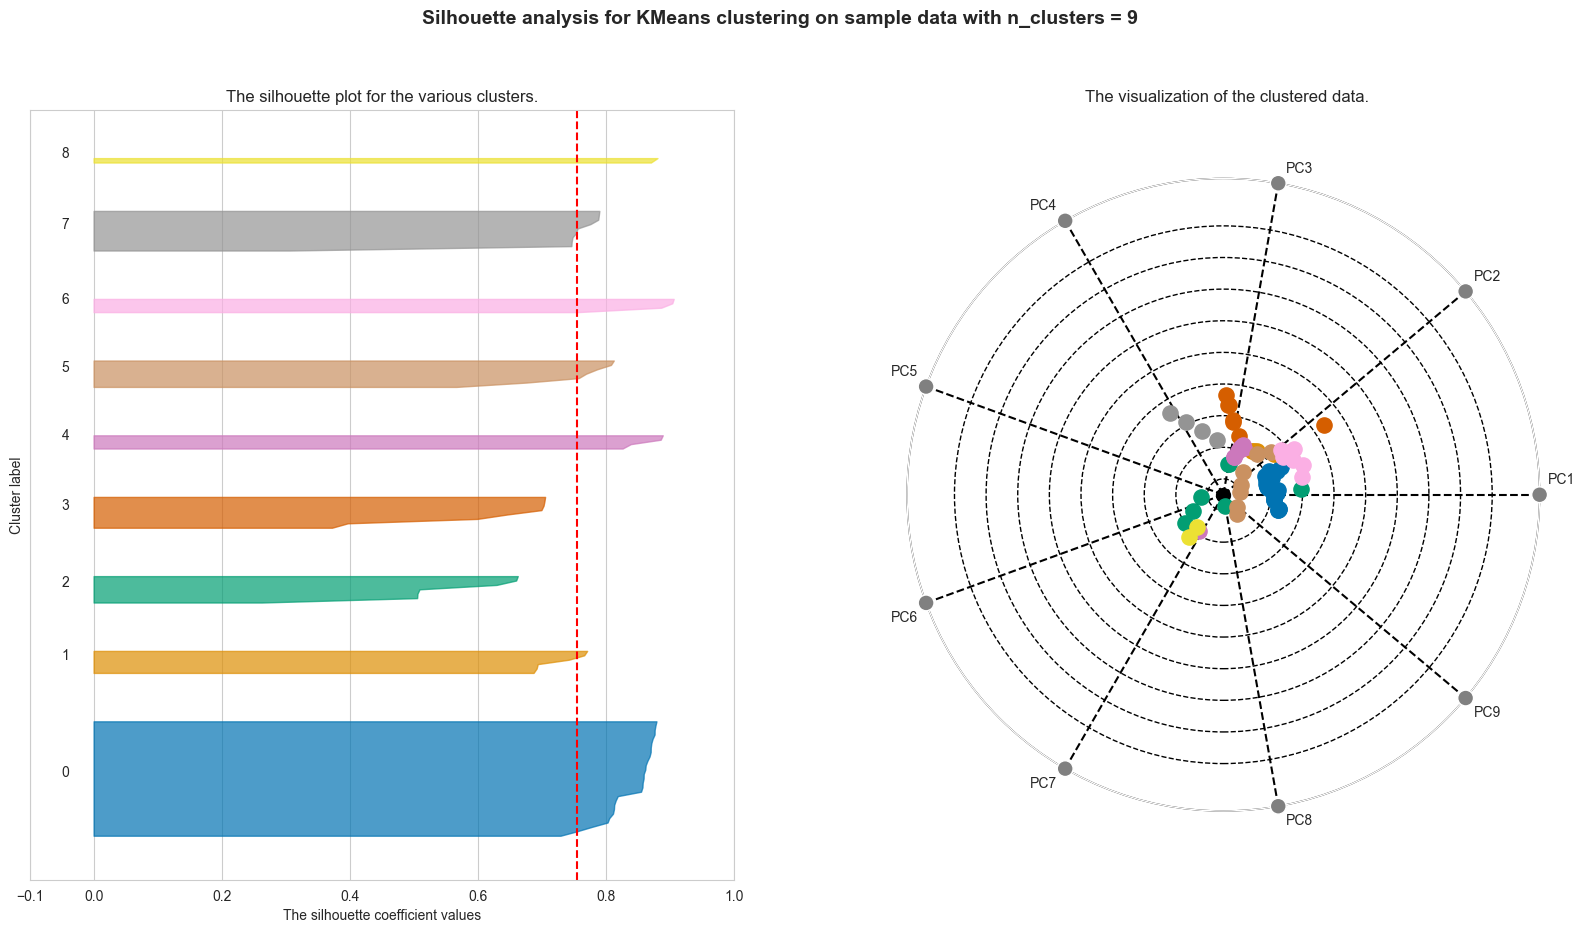

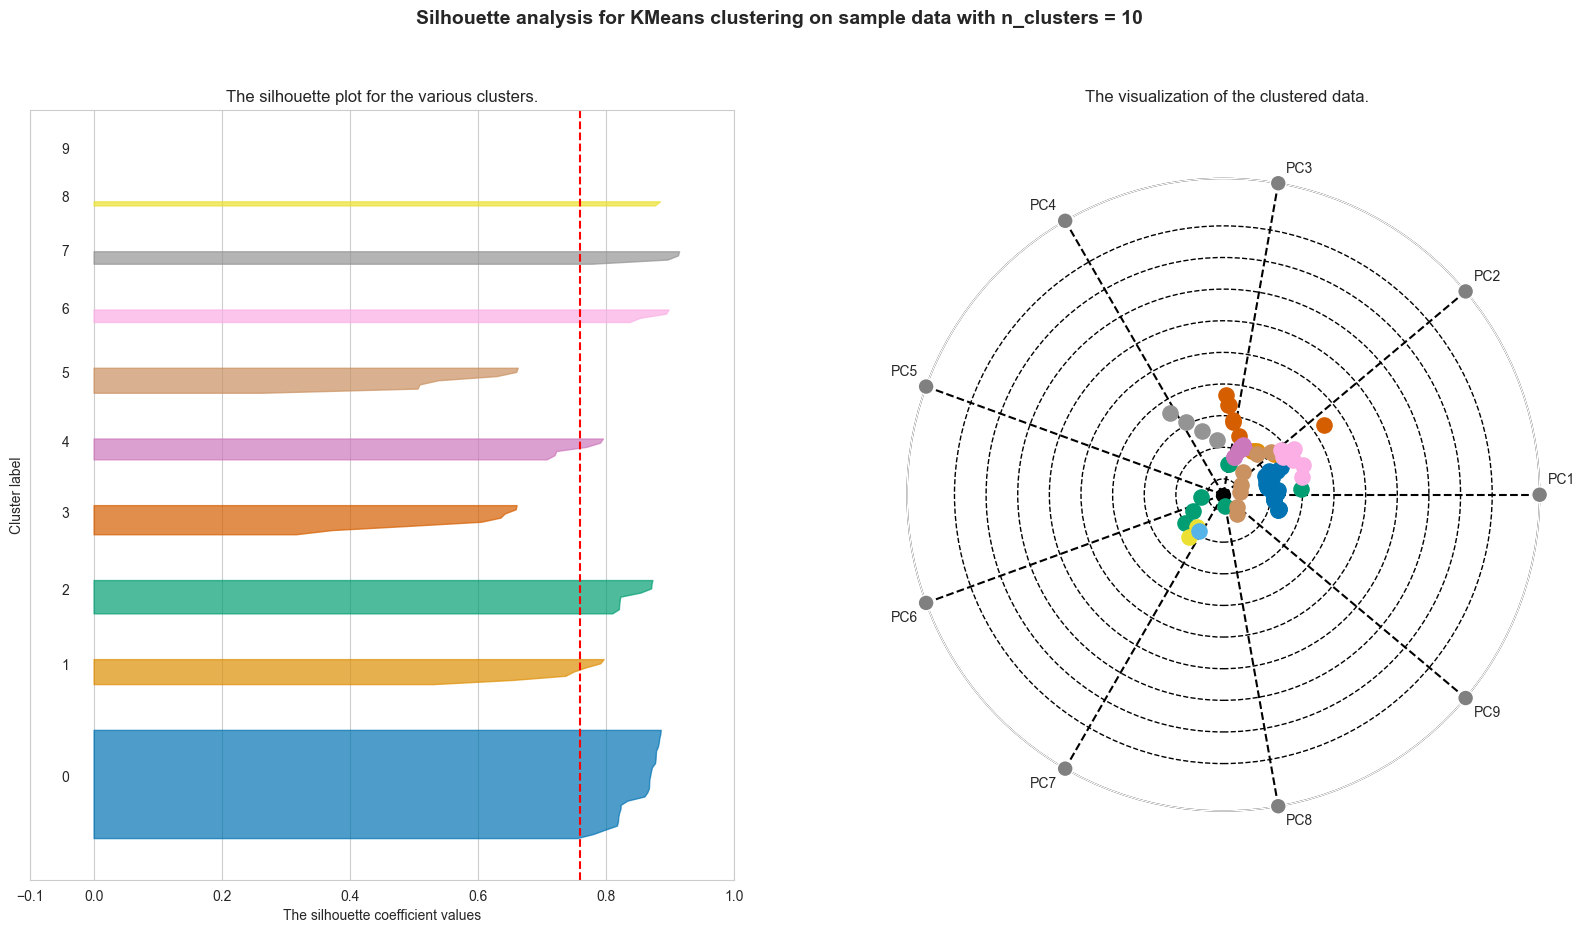

In [7]:
# Source for base code: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

range_n_clusters = range(2, 11)
inertiaList = []
cluster_list = []

for n_clusters in range_n_clusters:
    palette = sns.color_palette("colorblind", n_colors = n_clusters)
    opacity = 1.0
    color = [(*color, opacity) for color in palette]

    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(20, 10)

    # The 1st subplot is the silhouette plot
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(normalized) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value
    clusterer = KMeans(n_clusters=n_clusters, random_state=seed, max_iter=10000)
    #print(clusterer.get_params())

    cluster_labels = clusterer.fit_predict(normalized)
    cluster_list.append(cluster_labels)
    normalized["labels"] = cluster_labels
    #print(normalized["labels"].unique())

    # Store inertia values for elbow method
    inertia = clusterer.fit(normalized).inertia_
    #print(inertia)
    inertiaList.append(inertia)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(normalized, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(normalized, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color[i],
            edgecolor=color[i],
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])



    # 2nd Plot showing the actual clusters formed
    # colors = cm.viridis(cluster_labels.astype(float) / n_clusters)
    #
    # ax2.scatter(
    #     cluster_transform[:, 0], cluster_transform[:, 1], marker=".", s=50, lw=0, alpha=0.7, c=colors, edgecolor="k"
    # )
    radviz(dataframe = normalized, ax = ax2, labels = normalized.columns[-1], colors = color)

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )
    # Save the plot as a png file
    # filepath = os.path.join("../results/", f"Radviz_nClusters_{n_clusters}.png")
    # plt.savefig(filepath, bbox_inches = "tight")

plt.show()

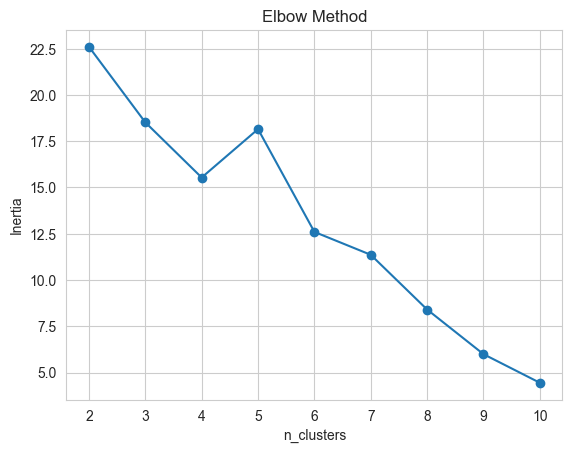

In [9]:
# Create plot for elbow method
plt.plot(range_n_clusters, inertiaList, marker = "o")

# Style plot
plt.title("Elbow Method")
plt.xlabel("n_clusters")
plt.ylabel("Inertia")
plt.grid(True)

# Display plot
plt.show()

# Hierarchical Clustering:

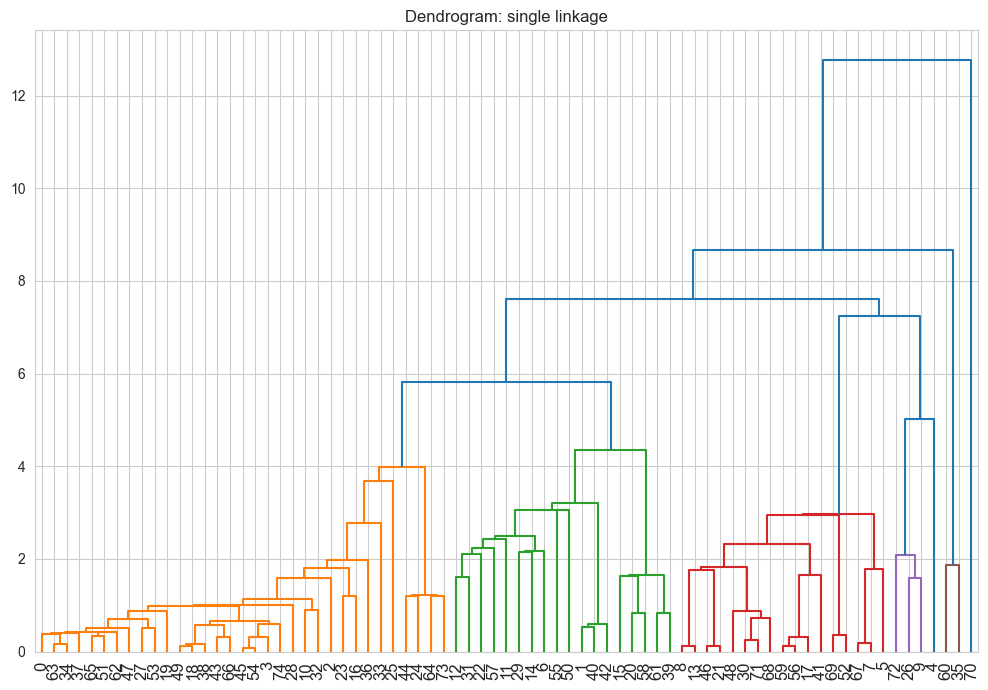

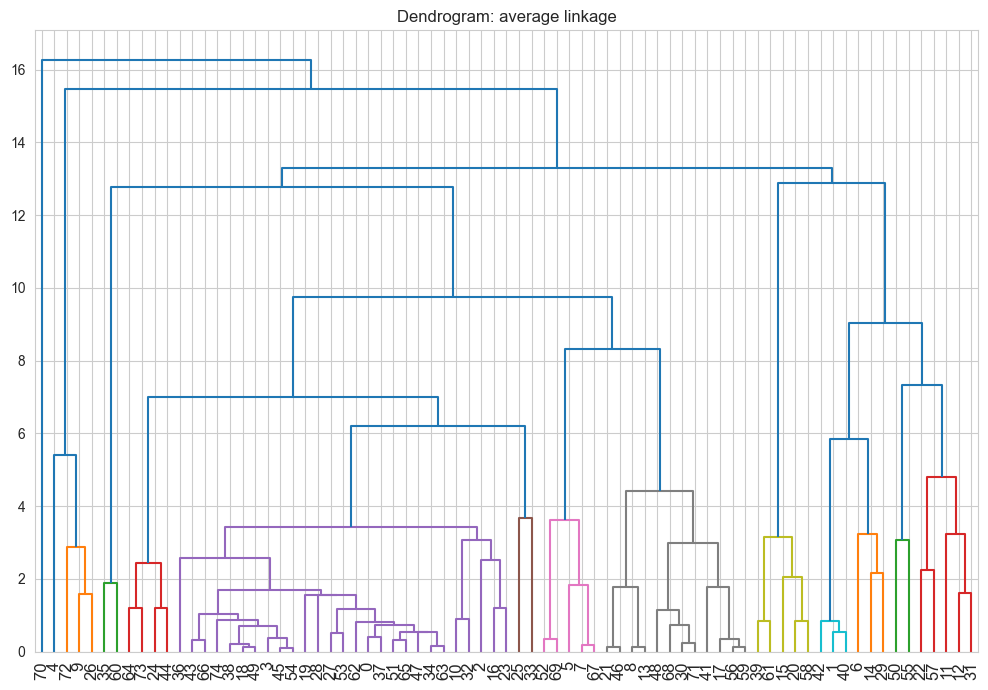

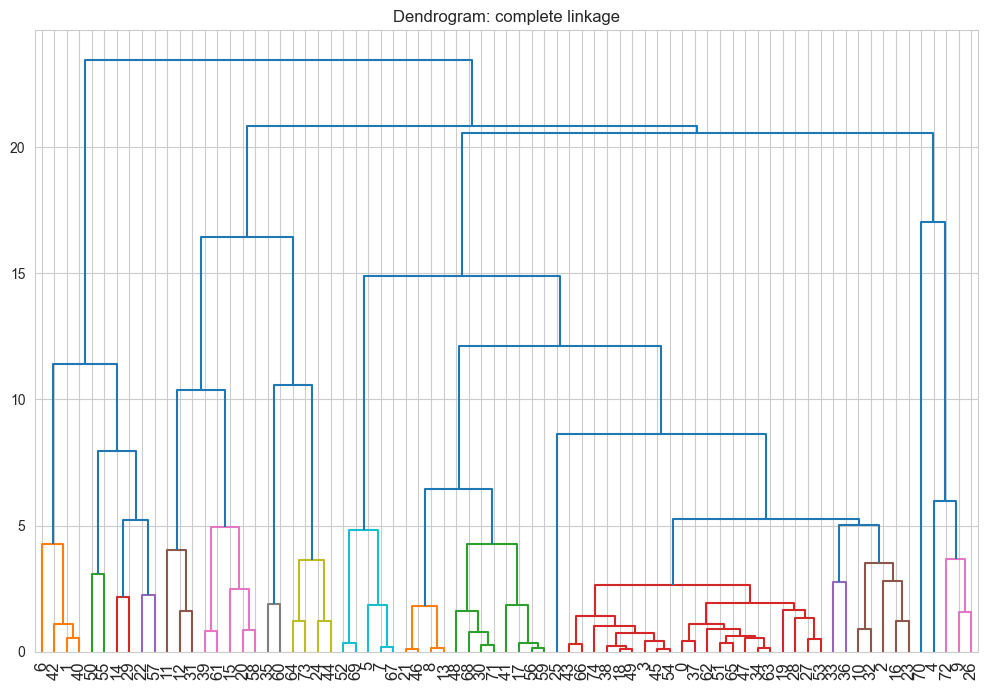

In [18]:
# Source of base code: https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html

def plot_dendrogram(model):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    plt.figure(figsize=(10, 7), layout = "tight")
    #plt.xlabel(fontsize="large")
    dendrogram(linkage_matrix, leaf_font_size = "large", color_threshold = 5)

for method in ["single", "average", "complete"]:
    # setting distance_threshold=0 ensures we compute the full tree.
    model = HierClustering(distance_threshold=0, n_clusters=None, linkage=method)

    model = model.fit(data)
    plot_dendrogram(model)
    plt.title(f"Dendrogram: {method} linkage")

    # plot the top three levels of the dendrogram
    #plot_dendrogram(model, truncate_mode="level", p=3)
    #plt.xlabel("Number of points in node (or index of point if no parenthesis).")

    # Save the plot as a png file
    # filepath = os.path.join("../results/", f"Dendrogram_method_{method}.png")
    # plt.savefig(filepath, bbox_inches = "tight")
    plt.show()

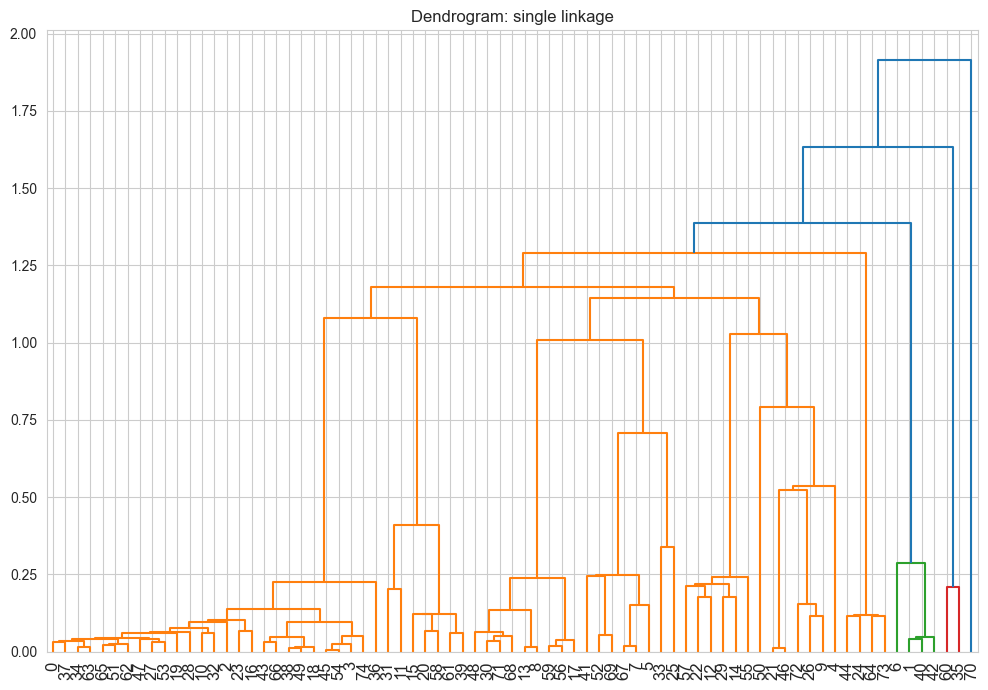

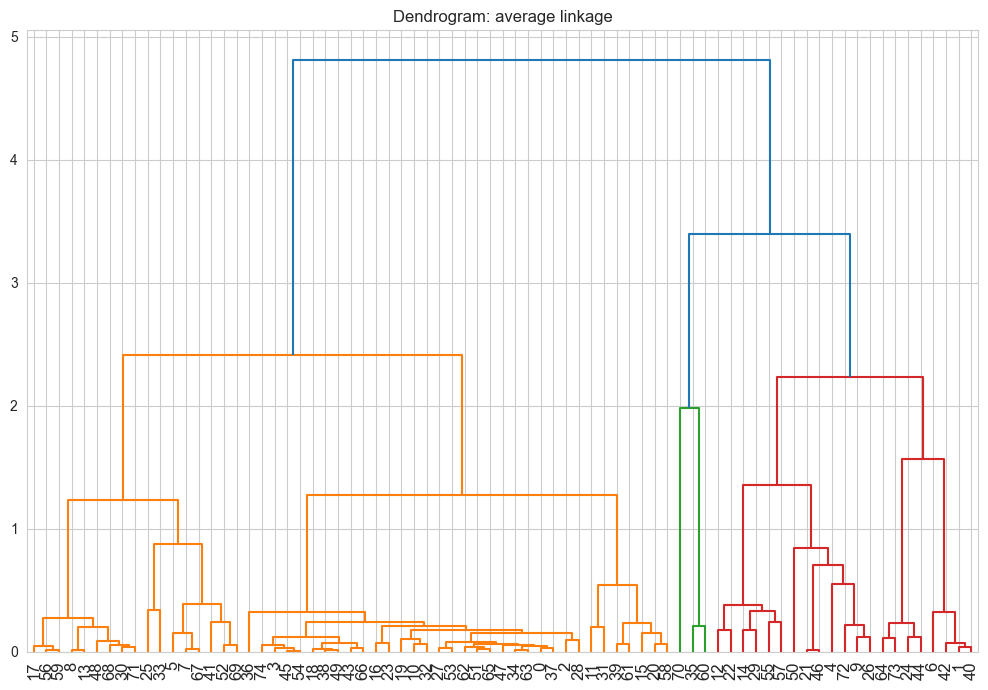

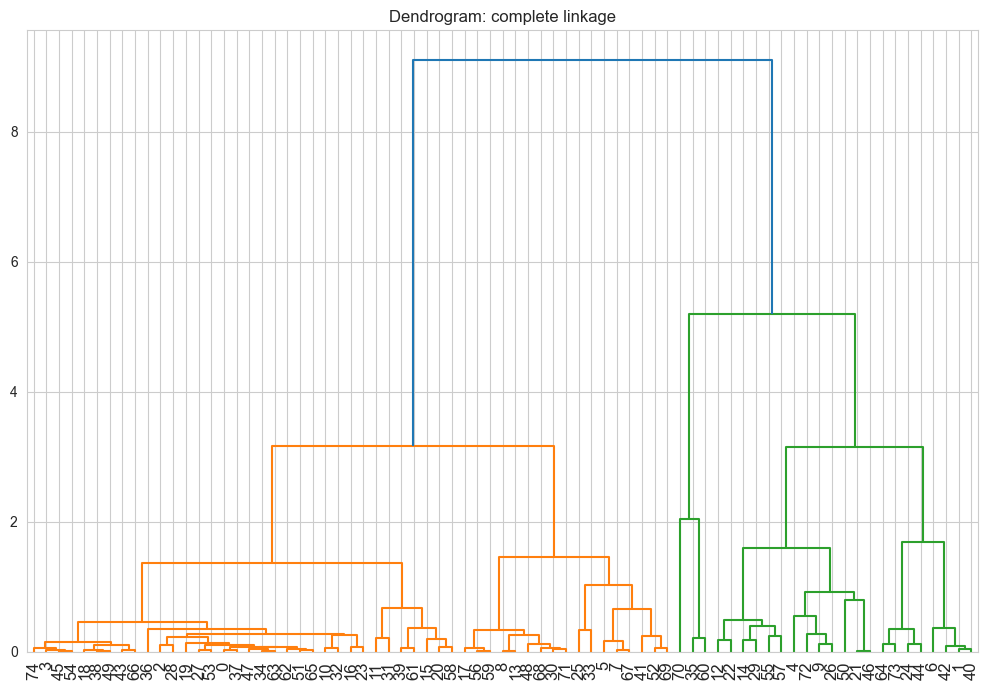

In [14]:
# Source of base code: https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html

def plot_dendrogram(model):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    plt.figure(figsize=(10, 7), layout = "tight")
    #plt.xlabel(fontsize="large")
    dendrogram(linkage_matrix, leaf_font_size = "large")

for method in ["single", "average", "complete"]:
    # setting distance_threshold=0 ensures we compute the full tree.
    model = HierClustering(distance_threshold=0, n_clusters=None, linkage=method)

    model = model.fit(normalized)
    plot_dendrogram(model)
    plt.title(f"Dendrogram: {method} linkage")

    # plot the top three levels of the dendrogram
    #plot_dendrogram(model, truncate_mode="level", p=3)
    #plt.xlabel("Number of points in node (or index of point if no parenthesis).")

    # Save the plot as a png file
    # filepath = os.path.join("../results/", f"Dendrogram_method_{method}.png")
    # plt.savefig(filepath, bbox_inches = "tight")
    plt.show()


# NOTE: Dendrogram gets squished at bottom if using normalized --> not the greatest